## Mini Projet : Comparaison de représentation classiquevs representation sémantique 

**Objectif** : Comparer des représentations textuelles classiques (TF-IDF) et sémantiques (Word2Vec, GloVe, fastText) pour la classification spam/ham en utilisant des RNNs sur les embeddings.



## Imports et configuration

In [67]:
import nltk
from nltk.corpus import stopwords
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score, f1_score
from sklearn.preprocessing import LabelEncoder
from gensim.models import Word2Vec, KeyedVectors
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, SimpleRNN, LSTM, GRU, Dropout, Bidirectional, GlobalMaxPooling1D
import tensorflow as tf
from collections import Counter
from wordcloud import WordCloud
from gensim.models import FastText
from tensorflow.keras.layers import Input, Embedding, Dense, LayerNormalization, MultiHeadAttention, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
import fasttext



In [68]:
tf.random.set_seed(42)
np.random.seed(42)

# Palette
PALETTE = {'ham': '#2ecc71', 'spam': '#e74c3c'}
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.titlesize': 13, 'axes.labelsize': 11})

## Prétraitement

In [69]:
df = pd.read_csv("./datasets/spam.csv", sep=",", encoding="latin-1") 
print("La taille du dataset: ", df.shape)
df.head()

La taille du dataset:  (5572, 5)


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [70]:
# Reperer les colonnes inutiles
print(df.columns)
# inspecter les colonnes
print("nb de valeurs nulles dans Unnamed: 2 :", df["Unnamed: 2"].isnull().sum())
print("nb de valeurs nulles dans Unnamed: 3 :", df["Unnamed: 3"].isnull().sum())
print("nb de valeurs nulles dans Unnamed: 4 :", df["Unnamed: 4"].isnull().sum())

# Supprimer les colonnes inutiles
df = df[['v1','v2']]
df.columns= ['label','message']
df.head()

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='str')
nb de valeurs nulles dans Unnamed: 2 : 5522
nb de valeurs nulles dans Unnamed: 3 : 5560
nb de valeurs nulles dans Unnamed: 4 : 5566


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [71]:
print("\nNombre des lignes en double:")
print(df.duplicated().sum())
df = df.drop_duplicates(subset='message').reset_index(drop=True)
print("Nombre des lignes en double après suppression:")
print(df.duplicated().sum())

print("\nClass distribution:")
print(df["label"].value_counts())



Nombre des lignes en double:
403
Nombre des lignes en double après suppression:
0

Class distribution:
label
ham     4516
spam     653
Name: count, dtype: int64


C:\Users\user\AppData\Local\Temp\ipykernel_23816\710618817.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1,0].boxplot(data_by_class, labels=['HAM','SPAM'],patch_artist=True, notch=True)


Text(0.5, 0, 'Fréquence')

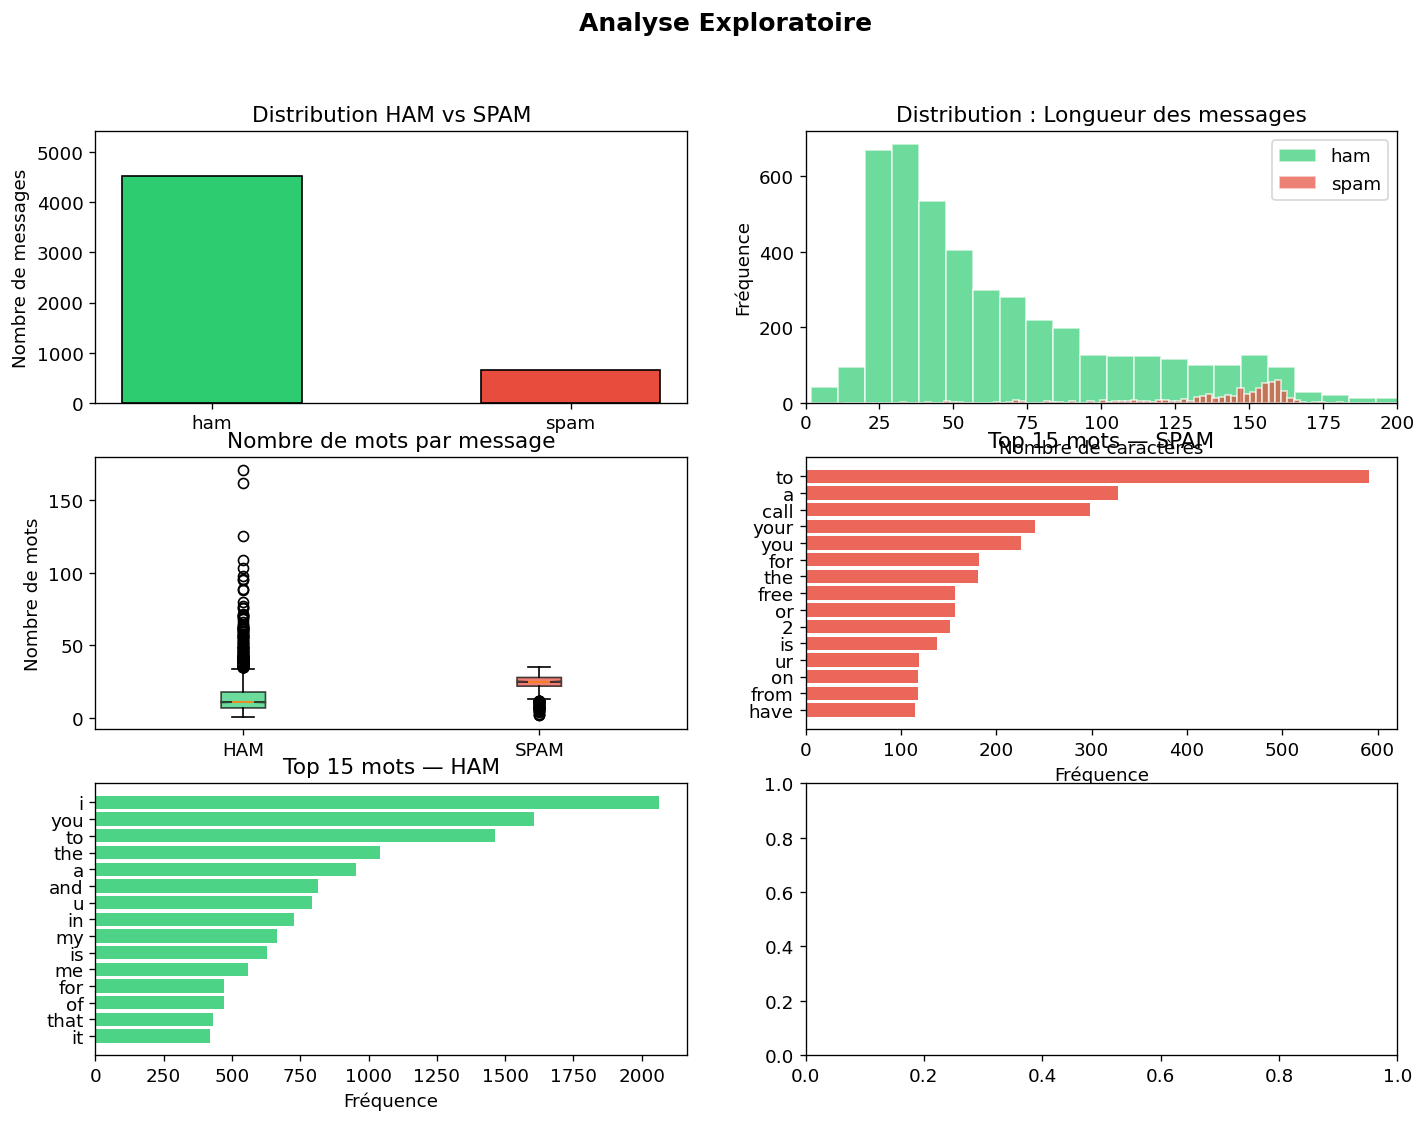

In [72]:
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
fig.suptitle("Analyse Exploratoire", fontsize=15, fontweight='bold')

# Distribution des classes
counts = df['label'].value_counts()
axes[0,0].bar(counts.index, counts.values,
              color=[PALETTE['ham'], PALETTE['spam']], edgecolor='black', width=0.5)

axes[0,0].set_title("Distribution HAM vs SPAM")
axes[0,0].set_ylabel("Nombre de messages")
axes[0,0].set_ylim(0, counts.max()*1.2)

# Distribution de la longueur des messages
for label, color in PALETTE.items():
    subset = df[df['label']==label]['message'].str.len()
    axes[0,1].hist(subset, bins=100, alpha=0.7, color=color, label=label, edgecolor='white')
axes[0,1].set_title("Distribution : Longueur des messages")
axes[0,1].set_xlabel("Nombre de caractères")
axes[0,1].set_ylabel("Fréquence")
axes[0,1].set_xlim(0, 200)
axes[0,1].legend()

# Boxplot : nombre de mots par classe
data_by_class = [df[df['label']=='ham']['message'].str.split().str.len().values,
                 df[df['label']=='spam']['message'].str.split().str.len().values]
bp = axes[1,0].boxplot(data_by_class, labels=['HAM','SPAM'],patch_artist=True, notch=True)
for patch, color in zip(bp['boxes'], [PALETTE['ham'], PALETTE['spam']]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1,0].set_title("Nombre de mots par message")
axes[1,0].set_ylabel("Nombre de mots")

# Top-20 mots spam vs ham
def top_words(series, n=20):
    all_words = []
    for msg in series:
        all_words.extend(str(msg).lower().split())
    common = Counter(all_words).most_common(n)
    return pd.DataFrame(common, columns=['word','count'])

spam_top = top_words(df[df['label']=='spam']['message'])
ham_top  = top_words(df[df['label']=='ham']['message'])

axes[1,1].barh(spam_top['word'][:15][::-1], spam_top['count'][:15][::-1],
               color=PALETTE['spam'], alpha=0.85)
axes[1,1].set_title("Top 15 mots — SPAM")
axes[1,1].set_xlabel("Fréquence")

axes[2,0].barh(ham_top['word'][:15][::-1], ham_top['count'][:15][::-1],
               color=PALETTE['ham'], alpha=0.85)
axes[2,0].set_title("Top 15 mots — HAM")
axes[2,0].set_xlabel("Fréquence")

## Interprétation des résultats

Lors de l'exploration de dataset : 
- la barre 'Distribution HAM vs SPAM' montre une imbalance (HAM > SPAM). 
Le modèle peut apprendre à dire “HAM” tout le temps et obtenir une bonne accuracy artificielle, donc accuracy seule n’est pas suffisante
- **Longueur des messages** : l'histogramme montre la répartition des tailles. 
    - HAM : surtout entre 20 et 100 caractères
    - SPAM : souvent plus long (100–160)

Les spam messages sont généralement : plus longs, plus “marketing”, contiennent plus d’instructions “Call now”, “free”, “win”, “text to…”

L’analyse des mots les plus fréquents dans les messages spam met en évidence des termes caractéristiques tels que “call”, “free”, “txt”, “text” et “now”. Ces mots traduisent une intention commerciale ou incitative, souvent associée aux campagnes publicitaires ou aux tentatives de fraude. En revanche, les messages ham contiennent principalement des mots fonctionnels comme “i”, “you”, “to”, “the” et “and”, ce qui reflète un langage naturel et conversationnel.


### Nettoyage de dataset

In [73]:
import re
from nltk.corpus import stopwords
STOPWORDS = set(stopwords.words('english'))

def preprocess(text):
    """
    Pipeline de nettoyage :
    1. Minuscules
    4. Suppression de la ponctuation et des chiffres
    5. Suppression des stopwords
    """
    text = text.lower()
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    tokens = text.split()
    tokens = [w for w in tokens if w not in STOPWORDS and len(w) > 1]
    return ' '.join(tokens)

df['clean'] = df['message'].apply(preprocess)

print("Exemples avant / après prétraitement :")
print("─"*70)
examples = df.sample(3, random_state=1)[['label','message','clean']]
for _, row in examples.iterrows():
    print(f"[{row['label'].upper()}]")
    print(f"  AVANT  : {row['message'][:80]}")
    print(f"  APRÈS  : {row['clean'][:80]}")
    print()

# Statistiques après nettoyage
print(f"Longueur moyenne après nettoyage : {df['clean'].str.len().mean():.1f} caractères")
print(f"Messages vides après nettoyage   : {(df['clean'].str.strip()=='').sum()}")

Exemples avant / après prétraitement :
──────────────────────────────────────────────────────────────────────
[HAM]
  AVANT  : I've been barred from all B and Q stores for life!?This twat in orange dungerees
  APRÈS  : barred stores life twat orange dungerees came asked wanted decking got first pun

[HAM]
  AVANT  : Gam gone after outstanding innings.
  APRÈS  : gam gone outstanding innings

[HAM]
  AVANT  : Am okay. Will soon be over. All the best
  APRÈS  : okay soon best

Longueur moyenne après nettoyage : 50.2 caractères
Messages vides après nettoyage   : 11


In [74]:
df.head()

,label,message,clean
0,ham,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis great wo...
1,ham,Ok lar... Joking wif u oni...,ok lar joking wif oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts 21s...
3,ham,U dun say so early hor... U c already then say...,dun say early hor already say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah think goes usf lives around though


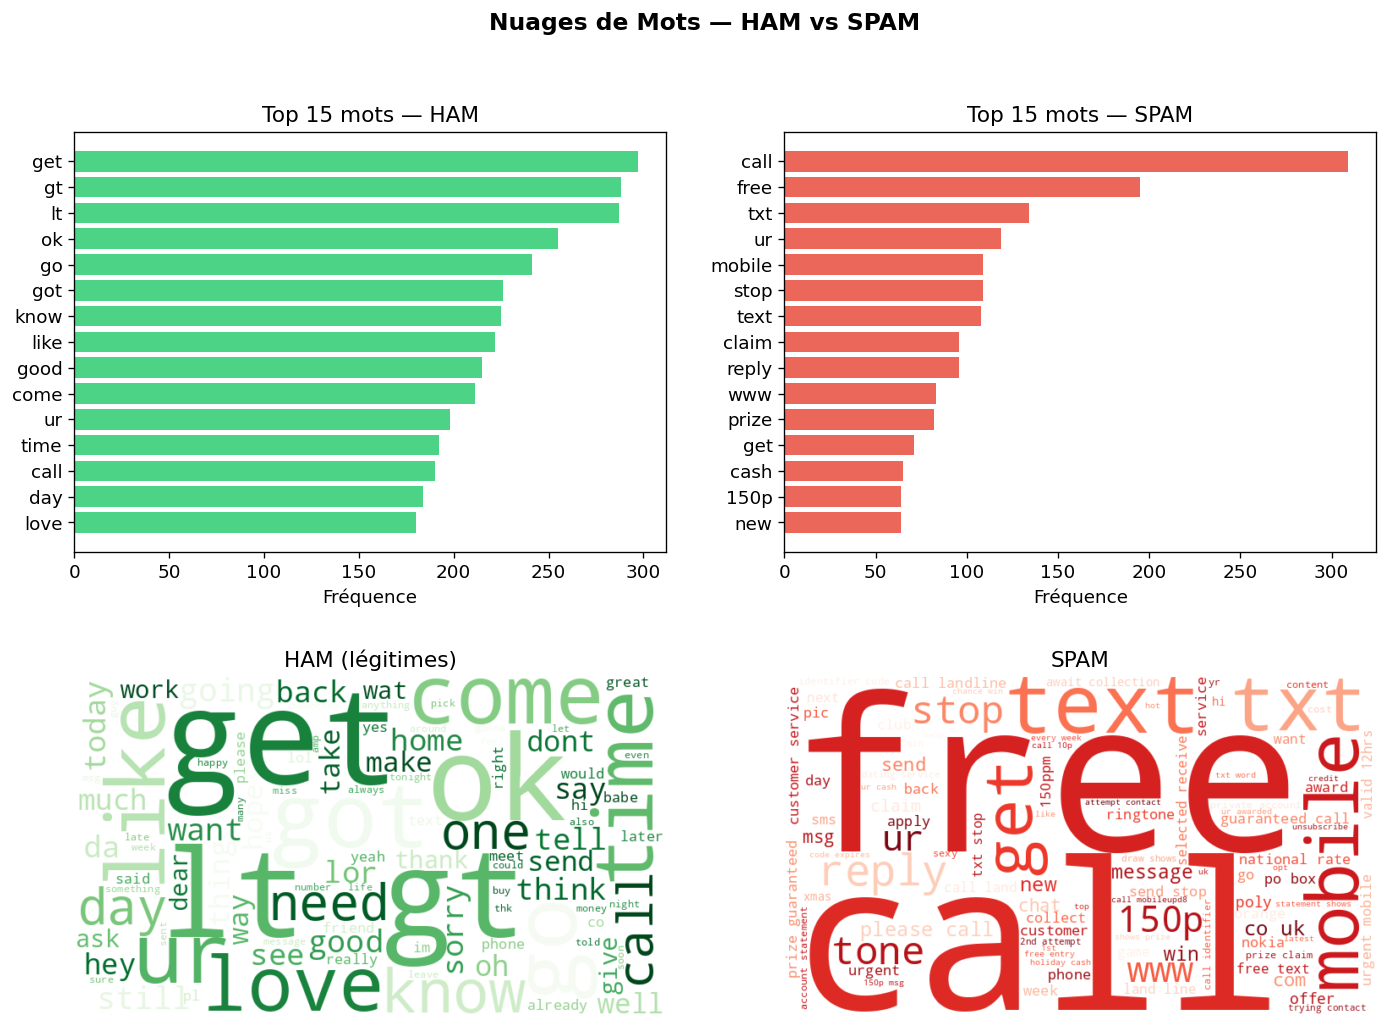

In [75]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
spam_top = top_words(df[df['label']=='spam']['clean'])
ham_top  = top_words(df[df['label']=='ham']['clean'])

axes[0,1].barh(spam_top['word'][:15][::-1], spam_top['count'][:15][::-1],
               color=PALETTE['spam'], alpha=0.85)
axes[0,1].set_title("Top 15 mots — SPAM")
axes[0,1].set_xlabel("Fréquence")

axes[0,0].barh(ham_top['word'][:15][::-1], ham_top['count'][:15][::-1],
               color=PALETTE['ham'], alpha=0.85)
axes[0,0].set_title("Top 15 mots — HAM")
axes[0,0].set_xlabel("Fréquence")

# Nuages de mots
ax3, ax4 = axes[1,0], axes[1,1]
fig.suptitle("Nuages de Mots — HAM vs SPAM", fontsize=14, fontweight='bold')

for ax, label, color in [(ax3, 'ham', 'Greens'), (ax4, 'spam', 'Reds')]:
    text = ' '.join(df[df['label']==label]['clean'].astype(str))
    wc   = WordCloud(width=700, height=400, background_color='white',
                     colormap=color, max_words=100,
                     stopwords=STOPWORDS).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f"{'HAM (légitimes)' if label=='ham' else 'SPAM'}", fontsize=13)
    ax.axis('off')

plt.show()

Pour les messages HAM, on observe des mots du langage quotidien comme `get, ok, go, know, like, good, love`, ce qui reflète des conversations naturelles entre personnes, avec un vocabulaire varié et sans objectif particulier de promotion. Le nuage de mots confirme cela en montrant une répartition équilibrée de termes courants.

Pour les messages SPAM, les mots les plus fréquents sont plutôt liés à la publicité ou aux arnaques, comme `call, free, claim, prize, cash, txt, mobile, reply`. On remarque aussi des termes qui incitent à agir rapidement ou à cliquer, ce qui est typique des messages commerciaux ou frauduleux. Le nuage de mots met en évidence une forte répétition de ces termes, ce qui montre un vocabulaire plus limité et orienté vers la persuasion.

Ainsi, cette analyse permet de voir clairement que les messages HAM sont naturels et variés, tandis que les SPAM utilisent un vocabulaire répétitif et orienté vers des actions ou des offres.


## Entrainement


### Sauvegarde des résultats

In [76]:
# --- Résultats: stockage + auto-sauvegarde ---
from pathlib import Path
import json
from typing import Any

# Dossier de sortie (créé si besoin)
RESULTS_DIR = Path("tmp")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

RESULTS_JSON_PATH = RESULTS_DIR / "results_spamham.json"
RESULTS_CSV_PATH = RESULTS_DIR / "results_spamham.csv"

def _to_builtin(value: Any):
    """Convertit les types numpy/pandas en types JSON-serializables."""
    try:
        import numpy as _np
        if isinstance(value, (_np.integer,)):
            return int(value)
        if isinstance(value, (_np.floating,)):
            return float(value)
        if isinstance(value, (_np.ndarray,)):
            return value.tolist()
    except Exception:
        pass
    if hasattr(value, "item") and callable(getattr(value, "item")):
        try:
            return value.item()
        except Exception:
            pass
    return value

def save_results(results_dict: dict, json_path: Path = RESULTS_JSON_PATH, csv_path: Path = RESULTS_CSV_PATH) -> None:
    """Sauvegarde robuste en JSON + CSV (lisible)."""
    payload: dict[str, dict[str, Any]] = {}
    for method, metrics in (results_dict or {}).items():
        if not isinstance(metrics, dict):
            continue
        payload[str(method)] = {str(k): _to_builtin(v) for k, v in metrics.items()}

    json_path.write_text(json.dumps(payload, ensure_ascii=False, indent=2), encoding="utf-8")

    # CSV: pratique pour le rapport (les dicts imbriqués restent en texte)
    try:
        import pandas as _pd
        df_export = _pd.DataFrame.from_dict(payload, orient="index").reset_index().rename(columns={"index": "Méthode"})
        df_export.to_csv(csv_path, index=False, encoding="utf-8-sig")
    except Exception as e:
        print(f"[WARN] Export CSV impossible: {e}")

def load_results(json_path: Path = RESULTS_JSON_PATH) -> dict:
    if not json_path.exists():
        return {}
    try:
        return json.loads(json_path.read_text(encoding="utf-8"))
    except Exception as e:
        print(f"[WARN] Fichier résultats illisible ({json_path}): {e}")
        return {}

class ResultsStore(dict):
    def __init__(self, *args, autosave: bool = True, **kwargs):
        super().__init__(*args, **kwargs)
        self._autosave = autosave

    def set_autosave(self, enabled: bool) -> None:
        self._autosave = bool(enabled)

    def __setitem__(self, key, value):
        super().__setitem__(key, value)
        if self._autosave:
            try:
                save_results(self)
            except Exception as e:
                print(f"[WARN] Auto-save échoué: {e}")

    def update(self, *args, **kwargs):
        super().update(*args, **kwargs)
        if self._autosave:
            try:
                save_results(self)
            except Exception as e:
                print(f"[WARN] Auto-save échoué: {e}")

# Ne pas écraser `results` si le kernel a déjà des résultats
if "results" not in globals() or not isinstance(results, dict):
    results = ResultsStore(autosave=True)
else:
    # enveloppe l'existant sans perdre les données
    results = ResultsStore(results, autosave=True)

# Recharge depuis disque (sans écraser ce qui est déjà en mémoire)
disk_results = load_results()
results.set_autosave(False)
for method, metrics in (disk_results or {}).items():
    if method not in results:
        results[method] = metrics
results.set_autosave(True)

# Sauvegarde une fois pour synchroniser les fichiers
save_results(results)
print(f"Résultats chargés/en mémoire: {len(results)} méthodes | JSON={RESULTS_JSON_PATH} | CSV={RESULTS_CSV_PATH}")

Résultats chargés/en mémoire: 16 méthodes | JSON=tmp\results_spamham.json | CSV=tmp\results_spamham.csv


In [77]:
import datetime

def log_result(
    method_key: str,
    accuracy: float,
    f1_score: float,
    auc_roc: float,
    elapsed_time: float,
    classification_report: str,
    metadata: dict = None,
    history: dict = None
) -> None:
    """
    Enregistre un résultat de modèle de manière standardisée et cohérente.
    
    Paramètres:
    -----------
    method_key : str
        Clé unique (ex: 'tfidf_rnn', 'w2v_lstm_smote', 'fasttext_gru')
        Sera forcée en minuscules avec tiret-bas
    accuracy : float
        Accuracy (0-1)
    f1_score : float
        F1-Score (0-1) 
    auc_roc : float
        AUC-ROC (0-1)
    elapsed_time : float
        Temps d'entraînement en secondes
    classification_report : str
        Rapport de classification complet
    metadata : dict, optional
        Infos additionnelles (architecture, représentation, etc.)
    history : dict, optional
        Historique de l'entraînement
    """
    # Normaliser la clé
    method_key = str(method_key).lower().replace(" ", "_")
    
    # Construire le payload
    entry = {
        "accuracy": float(accuracy),
        "f1_score": float(f1_score),
        "auc_roc": float(auc_roc),
        "time": float(elapsed_time),
        "report": str(classification_report),
        "timestamp": datetime.datetime.now().isoformat(),
    }
    
    if metadata:
        entry["metadata"] = metadata
    
    if history:
        entry["history"] = history
    
    # Enregistrer
    results[method_key] = entry
    
    # Affichage formaté
    print(f"\\n{'='*60}")
    print(f"✓ Résultat enregistré: {method_key.upper()}")
    print(f"{'='*60}")
    print(f"  Accuracy  : {accuracy:.4f}")
    print(f"  F1-Score  : {f1_score:.4f}")
    print(f"  AUC-ROC   : {auc_roc:.4f}")
    print(f"  Temps     : {elapsed_time:.2f}s")
    if metadata:
        for k, v in metadata.items():
            print(f"  {k.title()}: {v}")
    if history:
        print(f"  Historique: {len(history.get('loss', []))} epochs")
    print(f"  Sauvegardé: {RESULTS_JSON_PATH}")
    print(f"  Total en mémoire: {len(results)} modèles")
    print(f"{'='*60}\\n")

### 1. Implémentation d’un RNN (baseline)

### Tokenization and Padding

In [78]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(df['clean'])
sequences = tokenizer.texts_to_sequences(df['clean'])

max_len = max(len(seq) for seq in sequences)
padded_sequences = pad_sequences(sequences, maxlen=max_len)
pad_sequences

<function keras.src.utils.sequence_utils.pad_sequences(sequences, maxlen=None, dtype='int32', padding='pre', truncating='pre', value=0.0)>

In [79]:
# Encodage des labels & Split train/test
le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['label'])   

y = df['label_enc'].values

X_train, X_test, y_train, y_test = train_test_split(padded_sequences, y, test_size=0.2, random_state=42)
print(f"\nTrain : {len(X_train)} | Test : {len(X_test)}")
print(f"Spam dans train : {y_train.sum()} | Spam dans test : {y_test.sum()}")



Train : 4135 | Test : 1034
Spam dans train : 508 | Spam dans test : 145


### 1.1. SimpleRNN

In [80]:
max_words = len(tokenizer.word_index) + 1

t = time.time()
model = Sequential([
    Embedding(input_dim=max_words, output_dim=32),
    SimpleRNN(64),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.fit(
    X_train, y_train,
    epochs=5,
    validation_split=0.2,
    shuffle=True,
    batch_size=64
)

elapsed = time.time() - t
y_pred_prob = model.predict(X_test).flatten()
y_pred = (y_pred_prob > 0.5).astype(int)
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_prob)
report_text = classification_report(y_test, y_pred, target_names=le.classes_)

print(f"\nTest Accuracy: {acc:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"AUC-ROC: {auc:.4f}")
print(report_text)

log_result(
    method_key='rnn_only',
    accuracy=acc,
    f1_score=f1,
    auc_roc=auc,
    elapsed_time=elapsed,
    classification_report=report_text,
    metadata={'architecture': 'SimpleRNN(64)', 'representation': 'Embedding'},
    history=model.history.history
)

Epoch 1/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.8951 - loss: 0.2970 - val_accuracy: 0.9492 - val_loss: 0.1659
Epoch 2/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9634 - loss: 0.1256 - val_accuracy: 0.9758 - val_loss: 0.0823
Epoch 3/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9879 - loss: 0.0536 - val_accuracy: 0.9770 - val_loss: 0.0662
Epoch 4/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9870 - loss: 0.0454 - val_accuracy: 0.9807 - val_loss: 0.0502
Epoch 5/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9949 - loss: 0.0189 - val_accuracy: 0.9867 - val_loss: 0.0463
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step

Test Accuracy: 0.9826
F1-Score: 0.9366
AUC-ROC: 0.9972
              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       889
        spam       0.96      0.92      0.94       145

    accuracy                           0.98      1034
   macro avg       0.97      0.96      0.96      1034
wei

### 1.2. LSTM

In [81]:
max_words = len(tokenizer.word_index) + 1

import time
t0 = time.time()

model = Sequential([
    Embedding(input_dim=max_words, output_dim=64),
    LSTM(64),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.fit(
    X_train, y_train,
    epochs=5,
    validation_split=0.2,
    shuffle=True,
    batch_size=64
)

elapsed = time.time() - t0

y_pred_prob = model.predict(X_test).flatten()
y_pred = (y_pred_prob > 0.5).astype(int)
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_prob)
report_text = classification_report(y_test, y_pred, target_names=le.classes_)

print(f"\nTest Accuracy: {acc:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"AUC-ROC: {auc:.4f}")
print(report_text)

log_result(
    method_key='lstm_only',
    accuracy=acc,
    f1_score=f1,
    auc_roc=auc,
    elapsed_time=elapsed,
    classification_report=report_text,
    metadata={'architecture': 'LSTM(64)', 'representation': 'Embedding'},
    history=model.history.history
)

Epoch 1/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 20s 345ms/step - accuracy: 0.8966 - loss: 0.3101 - val_accuracy: 0.9565 - val_loss: 0.1505
Epoch 2/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - accuracy: 0.9773 - loss: 0.0978 - val_accuracy: 0.9819 - val_loss: 0.0539
Epoch 3/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.9909 - loss: 0.0344 - val_accuracy: 0.9879 - val_loss: 0.0385
Epoch 4/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.9961 - loss: 0.0157 - val_accuracy: 0.9855 - val_loss: 0.0406
Epoch 5/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.9982 - loss: 0.0083 - val_accuracy: 0.9903 - val_loss: 0.0382
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step

Test Accuracy: 0.9855
F1-Score: 0.9481
AUC-ROC: 0.9954
              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       889
        spam       0.95      0.94      0.95       145

    accuracy                           0.99      1034
   macro avg       0.97      0.97      0.97      1034


### 1.3. GRU

In [82]:
max_words = len(tokenizer.word_index) + 1
t0 = time.time()

model = Sequential([
    Embedding(input_dim=max_words, output_dim=64),
    GRU(64),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.fit(
    X_train, y_train,
    epochs=5,
    validation_split=0.2,
    shuffle=True,
    batch_size=64
)

elapsed = time.time() - t0

y_pred_prob = model.predict(X_test).flatten()
y_pred = (y_pred_prob > 0.5).astype(int)
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_prob)
report_text = classification_report(y_test, y_pred, target_names=le.classes_)

print(f"\nTest Accuracy: {acc:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"AUC-ROC: {auc:.4f}")
print(report_text)

log_result(
    method_key='gru_only',
    accuracy=acc,
    f1_score=f1,
    auc_roc=auc,
    elapsed_time=elapsed,
    classification_report=report_text,
    metadata={'architecture': 'GRU(64)', 'representation': 'Embedding'},
    history=model.history.history
)

Epoch 1/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - accuracy: 0.8721 - loss: 0.3532 - val_accuracy: 0.9480 - val_loss: 0.1481
Epoch 2/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.9773 - loss: 0.0887 - val_accuracy: 0.9843 - val_loss: 0.0413
Epoch 3/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.9918 - loss: 0.0280 - val_accuracy: 0.9891 - val_loss: 0.0324
Epoch 4/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.9976 - loss: 0.0127 - val_accuracy: 0.9891 - val_loss: 0.0302
Epoch 5/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.9988 - loss: 0.0074 - val_accuracy: 0.9915 - val_loss: 0.0301
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step

Test Accuracy: 0.9826
F1-Score: 0.9379
AUC-ROC: 0.9967
              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       889
        spam       0.94      0.94      0.94       145

    accuracy                           0.98      1034
   macro avg       0.96      0.96      0.96      1034
we

## 2. TF-IDF Vectorisation

In [83]:
# Encodage des labels & Split train/test
le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['label'])   

X = df['clean'].values
y = df['label_enc'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTrain : {len(X_train)} | Test : {len(X_test)}")
print(f"Spam dans train : {y_train.sum()} | Spam dans test : {y_test.sum()}")


Train : 4135 | Test : 1034
Spam dans train : 522 | Spam dans test : 131


In [84]:
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1,2), sublinear_tf=True)
X_train_tfidf = tfidf.fit_transform(X_train).toarray()
X_test_tfidf  = tfidf.transform(X_test).toarray()

print(f"Forme TF-IDF train : {X_train_tfidf.shape}")
print(f"Forme TF-IDF test  : {X_test_tfidf.shape}")
print(f"Dimension du vocabulaire : {len(tfidf.vocabulary_)}")

# Top TF-IDF features
feature_names = np.array(tfidf.get_feature_names_out())
mean_tfidf_spam = X_train_tfidf[y_train==1].mean(axis=0)
top_spam_features = feature_names[np.argsort(mean_tfidf_spam)[-20:]]
print(f"\nTop features TF-IDF (SPAM) : {list(top_spam_features[::-1])}")

mean_tfidf_ham = X_train_tfidf[y_train==0].mean(axis=0)
top_ham_features = feature_names[np.argsort(mean_tfidf_ham)[-20:]]
print(f"\nTop features TF-IDF (HAM) : {list(top_ham_features[::-1])}")

Forme TF-IDF train : (4135, 10000)
Forme TF-IDF test  : (1034, 10000)
Dimension du vocabulaire : 10000

Top features TF-IDF (SPAM) : ['call', 'free', 'text', 'txt', 'mobile', 'reply', 'stop', 'claim', 'ur', 'prize', 'www', 'uk', 'new', 'cash', 'urgent', 'please call', 'com', 'please', 'send', 'service']

Top features TF-IDF (HAM) : ['ok', 'get', 'know', 'come', 'gt', 'lt', 'like', 'got', 'good', 'going', 'lt gt', 'go', 'home', 'time', 'still', 'lor', 'call', 'want', 'ur', 'da']


### 2.1. SimpleRNN


In [85]:
X_tr_tfidf_r = X_train_tfidf.reshape(-1, 1, X_train_tfidf.shape[1])
X_te_tfidf_r = X_test_tfidf.reshape(-1,  1, X_test_tfidf.shape[1])

t0 = time.time()
model = Sequential([
    SimpleRNN(64, input_shape=(1, X_train_tfidf.shape[1])),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.fit(
    X_tr_tfidf_r, y_train,
    epochs=5,
    validation_split=0.2,
    shuffle=True,
    batch_size=64
)

elapsed = time.time() - t0

y_pred_prob = model.predict(X_te_tfidf_r).flatten()
y_pred = (y_pred_prob > 0.5).astype(int)
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_prob)
report_text = classification_report(y_test, y_pred, target_names=le.classes_)

print(f"\nTest Accuracy={acc:.4f}  F1={f1:.4f}  AUC={auc:.4f}  ({elapsed:.1f}s)")
print(report_text)

log_result(
    method_key='tfidf_rnn',
    accuracy=acc,
    f1_score=f1,
    auc_roc=auc,
    elapsed_time=elapsed,
    classification_report=report_text,
    metadata={'architecture': 'SimpleRNN(64)', 'representation': 'TF-IDF'},
    history=model.history.history
)

c:\Users\user\Desktop\CI-2\s2\text mining\miniprojet\text-mining\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.8670 - loss: 0.4892 - val_accuracy: 0.8960 - val_loss: 0.2459
Epoch 2/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9414 - loss: 0.1533 - val_accuracy: 0.9855 - val_loss: 0.0861
Epoch 3/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9885 - loss: 0.0454 - val_accuracy: 0.9915 - val_loss: 0.0506
Epoch 4/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9961 - loss: 0.0181 - val_accuracy: 0.9915 - val_loss: 0.0456
Epoch 5/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9982 - loss: 0.0089 - val_accuracy: 0.9915 - val_loss: 0.0455
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

Test Accuracy=0.9768  F1=0.9032  AUC=0.9909  (4.8s)
              precision    recall  f1-score   support

         ham       0.98      0.99      0.99       903
        spam       0.96      0.85      0.90       131

    accuracy                           0.98      1034
   macro avg       0.97      0.92      0.95      1034
weighte

### 2.2. LSTM


In [86]:
# LSTM sur TF-IDF
X_tr_tfidf_r = X_train_tfidf.reshape(-1, 1, X_train_tfidf.shape[1])
X_te_tfidf_r = X_test_tfidf.reshape(-1,  1, X_test_tfidf.shape[1])

t0 = time.time()
model = Sequential([
    LSTM(64, input_shape=(1, X_train_tfidf.shape[1])),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.fit(
    X_tr_tfidf_r, y_train,
    epochs=5,
    validation_split=0.2,
    shuffle=True,
    batch_size=64
)

elapsed = time.time() - t0

y_pred_prob = model.predict(X_te_tfidf_r).flatten()
y_pred = (y_pred_prob > 0.5).astype(int)
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_prob)
report_text = classification_report(y_test, y_pred, target_names=le.classes_)

print(f"\nTest Accuracy={acc:.4f}  F1={f1:.4f}  AUC={auc:.4f}  ({elapsed:.1f}s)")
print(report_text)

log_result(
    method_key='tfidf_lstm',
    accuracy=acc,
    f1_score=f1,
    auc_roc=auc,
    elapsed_time=elapsed,
    classification_report=report_text,
    metadata={'architecture': 'LSTM(64)', 'representation': 'TF-IDF'},
    history=model.history.history
)

Epoch 1/5


c:\Users\user\Desktop\CI-2\s2\text mining\miniprojet\text-mining\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.8691 - loss: 0.5884 - val_accuracy: 0.8791 - val_loss: 0.4180
Epoch 2/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.8845 - loss: 0.2734 - val_accuracy: 0.9299 - val_loss: 0.1750
Epoch 3/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.9613 - loss: 0.1205 - val_accuracy: 0.9819 - val_loss: 0.0863
Epoch 4/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.9876 - loss: 0.0504 - val_accuracy: 0.9891 - val_loss: 0.0554
Epoch 5/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.9937 - loss: 0.0250 - val_accuracy: 0.9903 - val_loss: 0.0476
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step

Test Accuracy=0.9739  F1=0.8907  AUC=0.9901  (10.9s)
              precision    recall  f1-score   support

         ham       0.98      0.99      0.99       903
        spam       0.95      0.84      0.89       131

    accuracy                           0.97      1034
   macro avg       0.96      0.92      0.94      1034
weighted avg  

### 2.3. GRU

In [87]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report
import time

# GRU sur TF-IDF
X_tr_tfidf_r = X_train_tfidf.reshape(-1, 1, X_train_tfidf.shape[1])
X_te_tfidf_r = X_test_tfidf.reshape(-1,  1, X_test_tfidf.shape[1])

t0 = time.time()
model = Sequential([
    GRU(64, input_shape=(1, X_train_tfidf.shape[1])),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.fit(
    X_tr_tfidf_r, y_train,
    epochs=5,
    validation_split=0.2,
    shuffle=True,
    batch_size=64
)

elapsed = time.time() - t0

y_pred_prob = model.predict(X_te_tfidf_r).flatten()
y_pred = (y_pred_prob > 0.5).astype(int)
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_prob)
report_text = classification_report(y_test, y_pred, target_names=le.classes_)

print(f"\nTest Accuracy={acc:.4f}  F1={f1:.4f}  AUC={auc:.4f}  ({elapsed:.1f}s)")
print(report_text)

log_result(
    method_key='tfidf_gru',
    accuracy=acc,
    f1_score=f1,
    auc_roc=auc,
    elapsed_time=elapsed,
    classification_report=report_text,
    metadata={'architecture': 'GRU(64)', 'representation': 'TF-IDF'},
    history=model.history.history
)

c:\Users\user\Desktop\CI-2\s2\text mining\miniprojet\text-mining\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 7s 49ms/step - accuracy: 0.8573 - loss: 0.5167 - val_accuracy: 0.8791 - val_loss: 0.2934
Epoch 2/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.8978 - loss: 0.2100 - val_accuracy: 0.9553 - val_loss: 0.1440
Epoch 3/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.9779 - loss: 0.0885 - val_accuracy: 0.9879 - val_loss: 0.0644
Epoch 4/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.9915 - loss: 0.0324 - val_accuracy: 0.9891 - val_loss: 0.0478
Epoch 5/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9964 - loss: 0.0156 - val_accuracy: 0.9891 - val_loss: 0.0446
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step

Test Accuracy=0.9739  F1=0.8907  AUC=0.9915  (14.3s)
              precision    recall  f1-score   support

         ham       0.98      0.99      0.99       903
        spam       0.95      0.84      0.89       131

    accuracy                           0.97      1034
   macro avg       0.96      0.92      0.94      1034
weigh

## 3. GloVe 


In [88]:
max_len = 200

tokenizer = Tokenizer()
tokenizer.fit_on_texts(X_train)
max_words = len(tokenizer.word_index) + 1
print("Number of unique words in dictionary =", len(tokenizer.word_index))

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad  = pad_sequences(X_test_seq, maxlen=max_len)

Number of unique words in dictionary = 7416


In [89]:
all_tokens = []
for text in list(X_train) + list(X_test):
    all_tokens.extend(text.split())
vocab = [w for w, c in Counter(all_tokens).items() if c >= 2]
vocab_size = len(vocab)
word2idx_glove = {w: i+1 for i, w in enumerate(vocab)}  # 0 = padding


embedding_index = {}
with open("./datasets/glove.6B/glove.6B.200d.txt", encoding="utf8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = values[1:]
        embedding_index[word] = vector

In [90]:
# Créer la matrice d'embeddings
embedding_dim = 200
word_index = tokenizer.word_index

embedding_matrix = np.zeros((max_words, embedding_dim))

for word, i in word_index.items():
    if i < max_words:
        vector = embedding_index.get(word)
        if vector is not None:
            embedding_matrix[i] = np.asarray(vector, dtype='float32')

### 3.1. SimpleRNN 


In [91]:
t0 = time.time()

model = Sequential([
    Embedding(
        input_dim=max_words,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        trainable=False
    ),
    SimpleRNN(64),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.fit(
    X_train_pad, y_train,
    epochs=5,
    validation_split=0.2,
    shuffle=True,
    batch_size=64
)

elapsed = time.time() - t0

y_pred_prob = model.predict(X_test_pad).flatten()
y_pred = (y_pred_prob > 0.5).astype(int)
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_prob)
report_text = classification_report(y_test, y_pred, target_names=le.classes_)

print(f"\nTest Accuracy={acc:.4f}  F1={f1:.4f}  AUC={auc:.4f}  ({elapsed:.1f}s)")
print(report_text)

log_result(
    method_key='glove_rnn',
    accuracy=acc,
    f1_score=f1,
    auc_roc=auc,
    elapsed_time=elapsed,
    classification_report=report_text,
    metadata={'architecture': 'SimpleRNN(64)', 'representation': 'GloVe(200d)'},
    history=model.history.history
)

Epoch 1/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 55ms/step - accuracy: 0.8431 - loss: 0.3446 - val_accuracy: 0.9698 - val_loss: 0.1046
Epoch 2/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.9722 - loss: 0.0888 - val_accuracy: 0.9746 - val_loss: 0.0737
Epoch 3/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.9810 - loss: 0.0623 - val_accuracy: 0.9758 - val_loss: 0.0647
Epoch 4/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.9858 - loss: 0.0468 - val_accuracy: 0.9807 - val_loss: 0.0651
Epoch 5/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.9885 - loss: 0.0364 - val_accuracy: 0.9794 - val_loss: 0.0573
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step

Test Accuracy=0.9720  F1=0.8854  AUC=0.9764  (13.1s)
              precision    recall  f1-score   support

         ham       0.98      0.99      0.98       903
        spam       0.92      0.85      0.89       131

    accuracy                           0.97      1034
   macro avg       0.95      0.92      0.93      1034
weig

### 3.2. LSTM 


In [92]:
t0 = time.time()

model = Sequential([
    Embedding(
        input_dim=max_words,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        trainable=False
    ),
    LSTM(64),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.fit(
    X_train_pad, y_train,
    epochs=5,
    validation_split=0.2,
    shuffle=True,
    batch_size=64
)

elapsed = time.time() - t0

y_pred_prob = model.predict(X_test_pad).flatten()
y_pred = (y_pred_prob > 0.5).astype(int)
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_prob)
report_text = classification_report(y_test, y_pred, target_names=le.classes_)

print(f"\nTest Accuracy={acc:.4f}  F1={f1:.4f}  AUC={auc:.4f}  ({elapsed:.1f}s)")
print(report_text)

log_result(
    method_key='glove_lstm',
    accuracy=acc,
    f1_score=f1,
    auc_roc=auc,
    elapsed_time=elapsed,
    classification_report=report_text,
    metadata={'architecture': 'LSTM(64)', 'representation': 'GloVe(200d)'},
    history=model.history.history
)

Epoch 1/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 10s 131ms/step - accuracy: 0.9117 - loss: 0.2711 - val_accuracy: 0.9770 - val_loss: 0.0897
Epoch 2/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 9s 112ms/step - accuracy: 0.9764 - loss: 0.0787 - val_accuracy: 0.9794 - val_loss: 0.0641
Epoch 3/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 7s 138ms/step - accuracy: 0.9858 - loss: 0.0531 - val_accuracy: 0.9843 - val_loss: 0.0567
Epoch 4/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 11s 142ms/step - accuracy: 0.9885 - loss: 0.0393 - val_accuracy: 0.9855 - val_loss: 0.0492
Epoch 5/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 8s 144ms/step - accuracy: 0.9933 - loss: 0.0302 - val_accuracy: 0.9831 - val_loss: 0.0513
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step

Test Accuracy=0.9758  F1=0.8971  AUC=0.9877  (45.2s)
              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       903
        spam       0.97      0.83      0.90       131

    accuracy                           0.98      1034
   macro avg       0.97      0.91      0.94      10

### 3.3. GRU 


In [93]:
t0 = time.time()

model = Sequential([
    Embedding(
        input_dim=max_words,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        trainable=False
    ),
    GRU(64),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.fit(
    X_train_pad, y_train,
    epochs=5,
    validation_split=0.2,
    shuffle=True,
    batch_size=64
)

elapsed = time.time() - t0

y_pred_prob = model.predict(X_test_pad).flatten()
y_pred = (y_pred_prob > 0.5).astype(int)
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_prob)
report_text = classification_report(y_test, y_pred, target_names=le.classes_)

print(f"\nTest Accuracy={acc:.4f}  F1={f1:.4f}  AUC={auc:.4f}  ({elapsed:.1f}s)")
print(report_text)

log_result(
    method_key='glove_gru',
    accuracy=acc,
    f1_score=f1,
    auc_roc=auc,
    elapsed_time=elapsed,
    classification_report=report_text,
    metadata={'architecture': 'GRU(64)', 'representation': 'GloVe(200d)'},
    history=model.history.history
)

Epoch 1/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 10s 136ms/step - accuracy: 0.8235 - loss: 0.3636 - val_accuracy: 0.9287 - val_loss: 0.1939
Epoch 2/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 109ms/step - accuracy: 0.9595 - loss: 0.1226 - val_accuracy: 0.9770 - val_loss: 0.0722
Epoch 3/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 119ms/step - accuracy: 0.9825 - loss: 0.0595 - val_accuracy: 0.9819 - val_loss: 0.0617
Epoch 4/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 7s 130ms/step - accuracy: 0.9861 - loss: 0.0456 - val_accuracy: 0.9746 - val_loss: 0.0710
Epoch 5/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 7s 133ms/step - accuracy: 0.9921 - loss: 0.0324 - val_accuracy: 0.9843 - val_loss: 0.0528
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step

Test Accuracy=0.9720  F1=0.8816  AUC=0.9905  (35.6s)
              precision    recall  f1-score   support

         ham       0.97      0.99      0.98       903
        spam       0.95      0.82      0.88       131

    accuracy                           0.97      1034
   macro avg       0.96      0.91      0.93      103

## 4. WORD2VEC

Expliation : Word2Vec est utilisé pour apprendre des vecteurs de mots à partir du corpus. Les étapes :
- Tokenizer le corpus d'entraînement,
- Entraîner Word2Vec (skip-gram ou CBOW) pour obtenir des vecteurs de dimension choisie,
- Construire pour chaque phrase une matrice (max_len × embed_dim) en remplaçant chaque mot par son vecteur,
- Ces matrices servent d'entrée 3D pour les modèles séquentiels (RNN/LSTM).

Remarque : Nous utilisons ici Word2Vec entraîné sur le corpus d'entraînement (ou sur le corpus augmenté après SMOTE).

### 4.1. SimpleRNN 


In [94]:
tokenized_corpus = [text.split() for text in X_train]

w2v_model = Word2Vec(
    sentences=tokenized_corpus,
    vector_size=50,      # dimension des vecteurs
    window=5,             # fenêtre de contexte
    min_count=2,          # ignorer les mots rares
    workers=4,
    sg=1,                 # Skip-gram
    epochs=10,
    seed=42
)

EMBED_DIM   = 50
MAX_SEQ_LEN = 100

def text_to_w2v_matrix(texts, model, embed_dim=EMBED_DIM, max_len=MAX_SEQ_LEN):
    """
    Convertit une liste de textes en matrices 3D (n, max_len, embed_dim).
    Chaque mot est remplacé par son vecteur Word2Vec.
    """
    X = np.zeros((len(texts), max_len, embed_dim), dtype=np.float32)
    for i, text in enumerate(texts):
        tokens = text.split()[:max_len]
        for j, word in enumerate(tokens):
            if word in model.wv:
                X[i, j] = model.wv[word]
    return X

X_tr_w2v = text_to_w2v_matrix(X_train, w2v_model, EMBED_DIM, MAX_SEQ_LEN)
X_te_w2v = text_to_w2v_matrix(X_test,  w2v_model, EMBED_DIM, MAX_SEQ_LEN)
print(f"Forme W2V train : {X_tr_w2v.shape}")
print(f"Forme W2V test  : {X_te_w2v.shape}")

Forme W2V train : (4135, 100, 50)
Forme W2V test  : (1034, 100, 50)


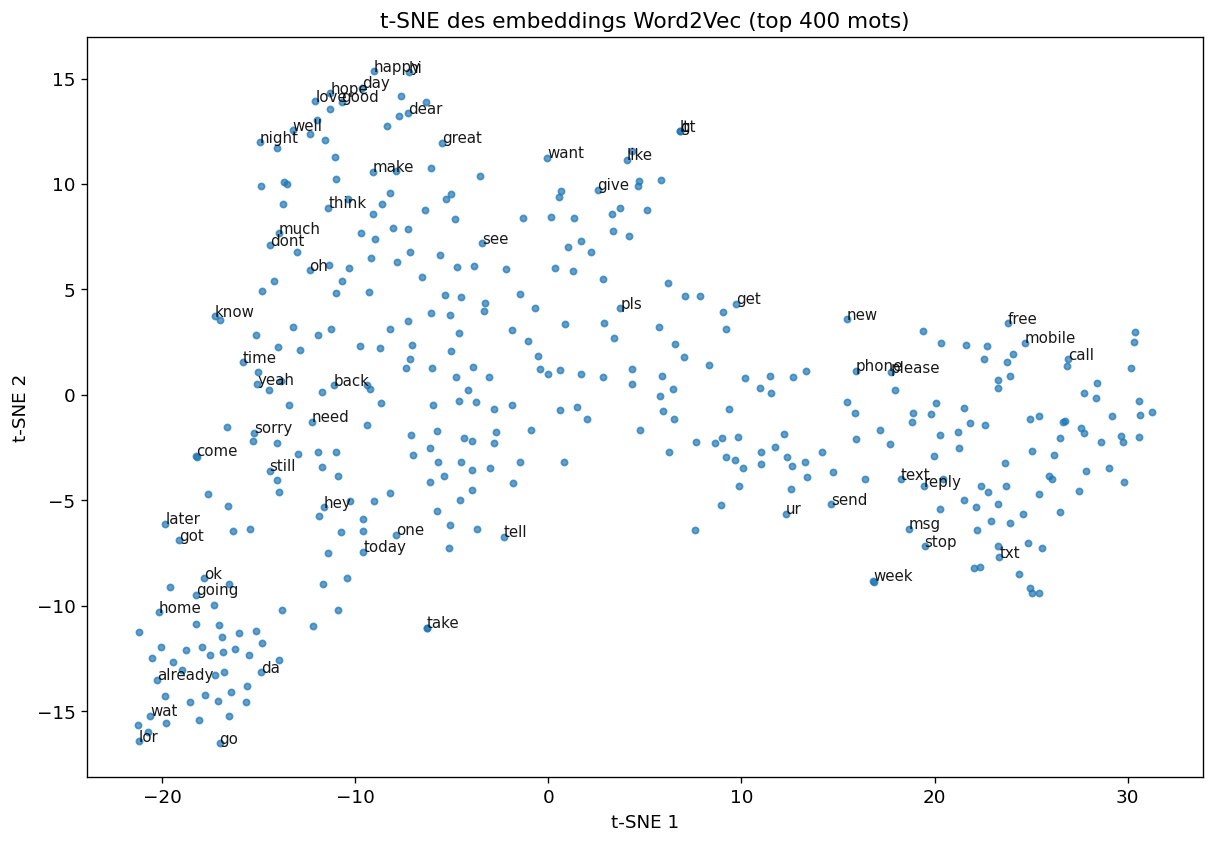

In [95]:
from sklearn.manifold import TSNE


n_words = 400   # nombre de mots projetés 
n_annot = 60    

words = w2v_model.wv.index_to_key[:n_words]                  # mots les plus fréquents
vectors = np.array([w2v_model.wv[w] for w in words])         # leurs vecteurs

tsne = TSNE(
    n_components=2,
    perplexity=30,
    init="pca",
    learning_rate="auto",
    random_state=42
)
emb_2d = tsne.fit_transform(vectors)

plt.figure(figsize=(12, 8))
plt.scatter(emb_2d[:, 0], emb_2d[:, 1], s=14, alpha=0.7)
plt.title(f"t-SNE des embeddings Word2Vec (top {n_words} mots)")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")

for i in range(min(n_annot, len(words))):
    plt.annotate(words[i], (emb_2d[i, 0], emb_2d[i, 1]), fontsize=9, alpha=0.9)

plt.show()

In [96]:
print(f"Taille du vocabulaire W2V : {len(w2v_model.wv)}")
print("\nMots les plus proches de 'free' :")
if 'free' in w2v_model.wv:
    for word, sim in w2v_model.wv.most_similar('free', topn=5):
        print(f"  {word:<15} similarité={sim:.4f}")
print("\nMots les plus proches de 'call' :")
if 'call' in w2v_model.wv:
    for word, sim in w2v_model.wv.most_similar('call', topn=5):
        print(f"  {word:<15} similarité={sim:.4f}")

Taille du vocabulaire W2V : 3244

Mots les plus proches de 'free' :
  colour          similarité=0.9443
  latest          similarité=0.9417
  ringtone        similarité=0.9390
  update          similarité=0.9342
  camcorder       similarité=0.9327

Mots les plus proches de 'call' :
  line            similarité=0.9389
  08712300220     similarité=0.9354
  claim           similarité=0.9323
  quoting         similarité=0.9284
  match           similarité=0.9207


## 4.1. SimpleRNN

In [97]:
t0 = time.time()

model = Sequential([
    SimpleRNN(64),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_tr_w2v, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    shuffle=True
)

elapsed = time.time() - t0

y_pred_prob = model.predict(X_te_w2v).flatten()
y_pred = (y_pred_prob > 0.5).astype(int)
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_prob)
report_text = classification_report(y_test, y_pred, target_names=le.classes_)

print(f"\nTest Accuracy={acc:.4f}  F1={f1:.4f}  AUC={auc:.4f}  ({elapsed:.1f}s)")
print(report_text)

log_result(
    method_key='w2v_rnn',
    accuracy=acc,
    f1_score=f1,
    auc_roc=auc,
    elapsed_time=elapsed,
    classification_report=report_text,
    metadata={'architecture': 'SimpleRNN(64)', 'representation': 'Word2Vec(50d)'},
    history=history.history
)

Epoch 1/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.9039 - loss: 0.2645 - val_accuracy: 0.9613 - val_loss: 0.1348
Epoch 2/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9704 - loss: 0.1037 - val_accuracy: 0.9734 - val_loss: 0.0818
Epoch 3/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9683 - loss: 0.0914 - val_accuracy: 0.9516 - val_loss: 0.1448
Epoch 4/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9749 - loss: 0.0885 - val_accuracy: 0.9553 - val_loss: 0.1256
Epoch 5/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9791 - loss: 0.0731 - val_accuracy: 0.9794 - val_loss: 0.0679
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step

Test Accuracy=0.9758  F1=0.9042  AUC=0.9877  (7.3s)
              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       903
        spam       0.91      0.90      0.90       131

    accuracy                           0.98      1034
   macro avg       0.95      0.94      0.95      1034
weight

## 4.2. LSTM

In [98]:
t0 = time.time()

model = Sequential([
    LSTM(64),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_tr_w2v, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    shuffle=True
)

elapsed = time.time() - t0

y_pred_prob = model.predict(X_te_w2v).flatten()
y_pred = (y_pred_prob > 0.5).astype(int)
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_prob)
report_text = classification_report(y_test, y_pred, target_names=le.classes_)

print(f"\nTest Accuracy={acc:.4f}  F1={f1:.4f}  AUC={auc:.4f}  ({elapsed:.1f}s)")
print(report_text)

log_result(
    method_key='w2v_lstm',
    accuracy=acc,
    f1_score=f1,
    auc_roc=auc,
    elapsed_time=elapsed,
    classification_report=report_text,
    metadata={'architecture': 'LSTM(64)', 'representation': 'Word2Vec(50d)'},
    history=history.history
)

Epoch 1/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - accuracy: 0.9193 - loss: 0.3343 - val_accuracy: 0.9710 - val_loss: 0.1336
Epoch 2/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.9589 - loss: 0.1730 - val_accuracy: 0.9698 - val_loss: 0.1378
Epoch 3/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.9586 - loss: 0.1727 - val_accuracy: 0.9698 - val_loss: 0.1377
Epoch 4/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.9586 - loss: 0.1731 - val_accuracy: 0.9698 - val_loss: 0.1373
Epoch 5/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.9595 - loss: 0.1712 - val_accuracy: 0.9746 - val_loss: 0.1204
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step

Test Accuracy=0.9613  F1=0.8246  AUC=0.9627  (12.3s)
              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       903
        spam       0.97      0.72      0.82       131

    accuracy                           0.96      1034
   macro avg       0.96      0.86      0.90      1034
weig

## 4.3. GRU

In [99]:
t0 = time.time()

model = Sequential([
    GRU(64),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_tr_w2v, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    shuffle=True
)

elapsed = time.time() - t0

y_pred_prob = model.predict(X_te_w2v).flatten()
y_pred = (y_pred_prob > 0.5).astype(int)
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_prob)
report_text = classification_report(y_test, y_pred, target_names=le.classes_)

print(f"\nTest Accuracy={acc:.4f}  F1={f1:.4f}  AUC={auc:.4f}  ({elapsed:.1f}s)")
print(report_text)

log_result(
    method_key='w2v_gru',
    accuracy=acc,
    f1_score=f1,
    auc_roc=auc,
    elapsed_time=elapsed,
    classification_report=report_text,
    metadata={'architecture': 'GRU(64)', 'representation': 'Word2Vec(50d)'},
    history=history.history
)

Epoch 1/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - accuracy: 0.8724 - loss: 0.5061 - val_accuracy: 0.8791 - val_loss: 0.3692
Epoch 2/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.8724 - loss: 0.3866 - val_accuracy: 0.8791 - val_loss: 0.3689
Epoch 3/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.8724 - loss: 0.3843 - val_accuracy: 0.8791 - val_loss: 0.3689
Epoch 4/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.8724 - loss: 0.3857 - val_accuracy: 0.8791 - val_loss: 0.3689
Epoch 5/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.8724 - loss: 0.3842 - val_accuracy: 0.8791 - val_loss: 0.3689
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step

Test Accuracy=0.8733  F1=0.0000  AUC=0.9124  (14.4s)
              precision    recall  f1-score   support

         ham       0.87      1.00      0.93       903
        spam       0.00      0.00      0.00       131

    accuracy                           0.87      1034
   macro avg       0.44      0.50      0.47      1034
weig

c:\Users\user\Desktop\CI-2\s2\text mining\miniprojet\text-mining\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\user\Desktop\CI-2\s2\text mining\miniprojet\text-mining\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\user\Desktop\CI-2\s2\text mining\miniprojet\text-mining\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control 

## Enhance F1-score using SMOTE on Embeddings

In [100]:
from imblearn.over_sampling import SMOTE
import numpy as np

# 1. Prepare your 3D W2V matrices as you did before
X_tr_w2v = text_to_w2v_matrix(X_train, w2v_model, EMBED_DIM, MAX_SEQ_LEN)
X_te_w2v = text_to_w2v_matrix(X_test,  w2v_model, EMBED_DIM, MAX_SEQ_LEN)

# 2. Reshape 3D -> 2D for SMOTE
# SMOTE needs (n_samples, MAX_SEQ_LEN * EMBED_DIM)
n_samples, seq_len, embed_dim = X_tr_w2v.shape
X_tr_flat = X_tr_w2v.reshape(n_samples, seq_len * embed_dim)

print(f"Flattened shape for SMOTE: {X_tr_flat.shape}")

# 3. Apply SMOTE
sm = SMOTE(random_state=42)
X_res_flat, y_res = sm.fit_resample(X_tr_flat, y_train)

# 4. Reshape back to 3D -> (n_resampled_samples, seq_len, embed_dim)
X_res_w2v = X_res_flat.reshape(-1, seq_len, embed_dim)

print(f"Resampled shape for LSTM: {X_res_w2v.shape}")
print(f"New class distribution: {np.bincount(y_res)}")

# 5. Build and Train LSTM
t0 = time.time()

model = Sequential([
    LSTM(64, input_shape=(MAX_SEQ_LEN, EMBED_DIM)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.fit(X_res_w2v, y_res, epochs=10, batch_size=64, validation_split=0.2)
elapsed = time.time() - t0

# 6. Evaluate
y_pred_prob = model.predict(X_te_w2v).flatten()
y_pred = (y_pred_prob > 0.5).astype(int)
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_prob)
report_text = classification_report(y_test, y_pred, target_names=le.classes_)

print(f"\nSMOTE + W2V LSTM Accuracy={acc:.4f} F1={f1:.4f} AUC={auc:.4f}")
print(report_text)

log_result(
    method_key='w2v_lstm_smote',
    accuracy=acc,
    f1_score=f1,
    auc_roc=auc,
    elapsed_time=elapsed,
    classification_report=report_text,
    metadata={'architecture': 'LSTM(64)', 'representation': 'Word2Vec(50d)', 'optimization': 'SMOTE'},
    history=model.history.history
)

Flattened shape for SMOTE: (4135, 5000)
Resampled shape for LSTM: (7226, 100, 50)
New class distribution: [3613 3613]
Epoch 1/10


c:\Users\user\Desktop\CI-2\s2\text mining\miniprojet\text-mining\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


91/91 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - accuracy: 0.8010 - loss: 0.4495 - val_accuracy: 0.6134 - val_loss: 0.7171
Epoch 2/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.8604 - loss: 0.3758 - val_accuracy: 0.6521 - val_loss: 0.6789
Epoch 3/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.8742 - loss: 0.3524 - val_accuracy: 0.6591 - val_loss: 0.6721
Epoch 4/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.8742 - loss: 0.3531 - val_accuracy: 0.6625 - val_loss: 0.6708
Epoch 5/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.8765 - loss: 0.3505 - val_accuracy: 0.6708 - val_loss: 0.6559
Epoch 6/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.8770 - loss: 0.3504 - val_accuracy: 0.6674 - val_loss: 0.6467
Epoch 7/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.8772 - loss: 0.3491 - val_accuracy: 0.6687 - val_loss: 0.6528
Epoch 8/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.8766 - loss: 0.3494 - val_accuracy: 0.6687 - val_loss: 0.

## 5. FastText


In [101]:
train_path = './tmp/ft_train.txt'
test_path  = './tmp/ft_test.txt'

def write_fasttext_file(path, texts, labels):
    with open(path, 'w', encoding='utf-8') as f:
        for msg, label in zip(texts, labels):
            lbl = '__label__spam' if label == 1 else '__label__ham'
            f.write(f"{lbl} {msg}\n")

write_fasttext_file(train_path, X_train, y_train)
write_fasttext_file(test_path, X_test, y_test)

In [102]:
ft_model = fasttext.train_supervised(
    input=train_path,
    dim=100,
    epoch=20,
    lr=0.1,
    wordNgrams=2,
    minCount=2,
    verbose=0
)

print("Vocab size:", len(ft_model.words))

result = ft_model.test(test_path)

print("Precision:", result[1])
print("Recall:", result[2])
print("Number of examples:", result[0])

Vocab size: 3245
Precision: 0.9796905222437138
Recall: 0.9796905222437138
Number of examples: 1034


In [103]:
MAX_LEN = 50
EMBED_DIM = 100

def text_to_ft_matrix(texts, ft_model):
    X = np.zeros((len(texts), MAX_LEN, EMBED_DIM), dtype=np.float32)

    for i, text in enumerate(texts):
        tokens = str(text).split()[:MAX_LEN]

        for j, word in enumerate(tokens):
            X[i, j] = ft_model.get_word_vector(word)

    return X

X_train_ft = text_to_ft_matrix(X_train, ft_model)
X_test_ft  = text_to_ft_matrix(X_test, ft_model)

print(X_train_ft.shape)

(4135, 50, 100)


## 5.1. SimpleRNN

In [104]:
t0 = time.time()

model = Sequential([
    SimpleRNN(64),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train_ft, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    shuffle=True
)

elapsed = time.time() - t0

y_pred_prob = model.predict(X_test_ft).flatten()
y_pred = (y_pred_prob > 0.5).astype(int)
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_prob)
report_text = classification_report(y_test, y_pred, target_names=le.classes_)

print(f"\nTest Accuracy={acc:.4f}  F1={f1:.4f}  AUC={auc:.4f}  ({elapsed:.1f}s)")
print(report_text)

log_result(
    method_key='fasttext_rnn',
    accuracy=acc,
    f1_score=f1,
    auc_roc=auc,
    elapsed_time=elapsed,
    classification_report=report_text,
    metadata={'architecture': 'SimpleRNN(64)', 'representation': 'FastText(100d)'},
    history=history.history
)

Epoch 1/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9640 - loss: 0.1486 - val_accuracy: 0.9891 - val_loss: 0.0515
Epoch 2/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9867 - loss: 0.0570 - val_accuracy: 0.9903 - val_loss: 0.0420
Epoch 3/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9888 - loss: 0.0443 - val_accuracy: 0.9940 - val_loss: 0.0361
Epoch 4/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9894 - loss: 0.0424 - val_accuracy: 0.9952 - val_loss: 0.0318
Epoch 5/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9900 - loss: 0.0367 - val_accuracy: 0.9927 - val_loss: 0.0370
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

Test Accuracy=0.9749  F1=0.9008  AUC=0.9761  (5.1s)
              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       903
        spam       0.90      0.90      0.90       131

    accuracy                           0.97      1034
   macro avg       0.94      0.94      0.94      1034
weighted 

## 5.2. LSTM

In [105]:
t0 = time.time()

model = Sequential([
    LSTM(64),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train_ft, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    shuffle=True
)

elapsed = time.time() - t0

y_pred_prob = model.predict(X_test_ft).flatten()
y_pred = (y_pred_prob > 0.5).astype(int)
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_prob)
report_text = classification_report(y_test, y_pred, target_names=le.classes_)

print(f"\nTest Accuracy={acc:.4f}  F1={f1:.4f}  AUC={auc:.4f}  ({elapsed:.1f}s)")
print(report_text)

log_result(
    method_key='fasttext_lstm',
    accuracy=acc,
    f1_score=f1,
    auc_roc=auc,
    elapsed_time=elapsed,
    classification_report=report_text,
    metadata={'architecture': 'LSTM(64)', 'representation': 'FastText(100d)'},
    history=history.history
)

Epoch 1/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.9411 - loss: 0.2658 - val_accuracy: 0.9661 - val_loss: 0.1252
Epoch 2/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9825 - loss: 0.0814 - val_accuracy: 0.9927 - val_loss: 0.0439
Epoch 3/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9897 - loss: 0.0379 - val_accuracy: 0.9843 - val_loss: 0.0498
Epoch 4/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9882 - loss: 0.0409 - val_accuracy: 0.9891 - val_loss: 0.0331
Epoch 5/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9900 - loss: 0.0340 - val_accuracy: 0.9891 - val_loss: 0.0357
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

Test Accuracy=0.9720  F1=0.8755  AUC=0.9803  (7.6s)
              precision    recall  f1-score   support

         ham       0.97      1.00      0.98       903
        spam       1.00      0.78      0.88       131

    accuracy                           0.97      1034
   macro avg       0.98      0.89      0.93      1034
weigh

## 5.3. GRU

In [106]:
t0 = time.time()

model = Sequential([
    GRU(64),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train_ft, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    shuffle=True
)

elapsed = time.time() - t0

y_pred_prob = model.predict(X_test_ft).flatten()
y_pred = (y_pred_prob > 0.5).astype(int)
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_prob)
report_text = classification_report(y_test, y_pred, target_names=le.classes_)

print(f"\nTest Accuracy={acc:.4f}  F1={f1:.4f}  AUC={auc:.4f}  ({elapsed:.1f}s)")
print(report_text)

log_result(
    method_key='fasttext_gru',
    accuracy=acc,
    f1_score=f1,
    auc_roc=auc,
    elapsed_time=elapsed,
    classification_report=report_text,
    metadata={'architecture': 'GRU(64)', 'representation': 'FastText(100d)'},
    history=history.history
)

Epoch 1/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.8721 - loss: 0.4818 - val_accuracy: 0.8791 - val_loss: 0.3643
Epoch 2/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.8727 - loss: 0.3193 - val_accuracy: 0.9782 - val_loss: 0.1182
Epoch 3/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9807 - loss: 0.0737 - val_accuracy: 0.9831 - val_loss: 0.0592
Epoch 4/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9873 - loss: 0.0556 - val_accuracy: 0.9952 - val_loss: 0.0355
Epoch 5/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9918 - loss: 0.0293 - val_accuracy: 0.9952 - val_loss: 0.0268
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step

Test Accuracy=0.9768  F1=0.9000  AUC=0.9792  (8.7s)
              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       903
        spam       0.99      0.82      0.90       131

    accuracy                           0.98      1034
   macro avg       0.98      0.91      0.94      1034
weight

# Analyse des résultats et optimisation 

In [107]:
def extract_f1_from_report(report, target_label="spam"):
    """
    Extrait le F1-score de la classe cible depuis la chaîne classification_report.
    Si la classe n'est pas trouvée, utilise le weighted avg.
    """
    if not isinstance(report, str):
        return np.nan
    lines = report.splitlines()
    for line in lines:
        if line.strip().startswith(target_label):
            parts = line.split()
            # label precision recall f1-score support
            if len(parts) >= 5:
                try:
                    return float(parts[3])
                except ValueError:
                    pass
    for line in lines:
        if line.strip().startswith("weighted avg"):
            parts = line.split()
            if len(parts) >= 5:
                try:
                    return float(parts[3])
                except ValueError:
                    pass
    return np.nan

def infer_representation_and_architecture(method_name):
    """Infer representation type and architecture from method name"""
    m = method_name.lower()
    
    if m == "rnn_only":
        return "Embedding appris", "RNN", "Embedding 32d + RNN 64"
    elif m == "lstm_only":
        return "Embedding appris", "LSTM", "Embedding 64d + LSTM 64"
    elif m == "gru_only":
        return "Embedding appris", "GRU", "Embedding 64d + GRU 64"
    
    # TF-IDF models
    if m.startswith("tfidf_"):
        arch = m.split("_")[1].upper()
        return "TF-IDF", arch, "max_features=10000"
    
    # GloVe models
    if m.startswith("glove_"):
        arch = m.split("_")[1].upper()
        return "GloVe", arch, "200d préentraîné"
    
    # Word2Vec models
    if m.startswith("w2v_"):
        arch = m.split("_")[1].upper()
        if "smote" in m:
            return "Word2Vec", arch, "50d + SMOTE"
        return "Word2Vec", arch, "50d"
    
    # FastText models
    if m.startswith("fasttext_"):
        parts = m.split("_")
        arch = parts[1].upper()
        if "smote" in m:
            if "_128" in m:
                return "FastText", arch, "100d + SMOTE + 128u"
            return "FastText", arch, "100d + SMOTE"
        return "FastText", arch, "100d"
    
    return "N/A", "N/A", "N/A"

# Build comprehensive results dataframe
rows = []
for method_name, metrics in results.items():
    if not isinstance(metrics, dict):
        continue
    
    rep, arch, param = infer_representation_and_architecture(method_name)
    if rep == "N/A":
        continue
    
    rows.append({
        "Méthode": method_name,
        "Représentation": rep,
        "Architecture": arch,
        "Config": param,
        "Accuracy": metrics.get("accuracy", np.nan),
        "F1-Score": metrics.get("f1_score", np.nan),
        "AUC-ROC": metrics.get("auc_roc", metrics.get("auc", np.nan)),
        "Temps (s)": metrics.get("elapsed_time", metrics.get("time", np.nan)),
    })

comparatif = pd.DataFrame(rows).sort_values(["F1-Score", "Accuracy"], ascending=False).reset_index(drop=True)

print(f"Total methods: {len(comparatif)}")
print("TABLEAU COMPARATIF - TOUS LES RÉSULTATS")
display(comparatif[[
    "Méthode", "Représentation", "Architecture", "Accuracy", "F1-Score", "AUC-ROC", "Temps (s)"
]])

Total methods: 16
TABLEAU COMPARATIF - TOUS LES RÉSULTATS


,Méthode,Représentation,Architecture,Accuracy,F1-Score,AUC-ROC,Temps (s)
0,lstm_only,Embedding appris,LSTM,0.985493,0.948097,0.995423,31.541692
1,gru_only,Embedding appris,GRU,0.982592,0.937931,0.996656,13.354676
2,rnn_only,Embedding appris,RNN,0.982592,0.936620,0.997246,5.686665
3,w2v_rnn,Word2Vec,RNN,0.975822,0.904215,0.987742,7.347913
4,tfidf_rnn,TF-IDF,RNN,0.976789,0.903226,0.990938,4.830741
5,fasttext_rnn,FastText,RNN,0.974855,0.900763,0.976127,5.094962
6,fasttext_gru,FastText,GRU,0.976789,0.900000,0.979153,8.747015
7,glove_lstm,GloVe,LSTM,0.975822,0.897119,0.987704,45.201773
8,tfidf_lstm,TF-IDF,LSTM,0.973888,0.890688,0.990067,10.922126
9,tfidf_gru,TF-IDF,GRU,0.973888,0.890688,0.991462,14.343182


In [108]:
print("MEILLEURE MÉTHODE")
print("="*80)
best = comparatif.iloc[0]
print(f"\nMéthode: {best['Méthode']}")
print(f"Représentation: {best['Représentation']}")
print(f"Architecture: {best['Architecture']}")
print(f"Accuracy: {best['Accuracy']:.4f}")
print(f"F1-Score: {best['F1-Score']:.4f}")
print(f"AUC-ROC: {best['AUC-ROC']:.4f}")
print(f"Temps: {best['Temps (s)']:.2f}s")


MEILLEURE MÉTHODE

Méthode: lstm_only
Représentation: Embedding appris
Architecture: LSTM
Accuracy: 0.9855
F1-Score: 0.9481
AUC-ROC: 0.9954
Temps: 31.54s


In [109]:
# Afficher uniquement les résultats des méthodes "optimisées" (SMOTE et/ou variante _128)

def get_optimization_label(method_name: str) -> str:
    """Extract optimization flags from method name"""
    m = method_name.lower()
    labels = []
    if "smote" in m:
        labels.append("SMOTE")
    if "_128" in m:
        labels.append("LSTM 128u")
    return " + ".join(labels) if labels else ""

# Filter optimized methods
optim_methods = [
    method for method in results.keys()
    if ("smote" in method.lower()) or ("_128" in method.lower())
]

rows_optim = []
for method in optim_methods:
    metrics = results.get(method, {})
    rep, arch, param = infer_representation_and_architecture(method)
    optim_label = get_optimization_label(method)
    
    rows_optim.append({
        "Méthode": method,
        "Optimisation": optim_label,
        "Représentation": rep,
        "Architecture": arch,
        "Accuracy": metrics.get("accuracy", np.nan),
        "F1-Score": metrics.get("f1_score", np.nan),
        "AUC-ROC": metrics.get("auc_roc", metrics.get("auc", np.nan)),
        "Temps (s)": metrics.get("elapsed_time", metrics.get("time", np.nan)),
    })

if rows_optim:
    optim_results_df = pd.DataFrame(rows_optim).sort_values(["F1-Score", "Accuracy"], ascending=False)
    print("RÉSULTATS OPTIMISÉS (SMOTE / Variantes 128 unités)")
    display(optim_results_df[[
        "Méthode", "Optimisation", "Représentation", "Architecture", 
        "Accuracy", "F1-Score", "AUC-ROC", "Temps (s)"
    ]].reset_index(drop=True))
else:
    print("Aucune méthode optimisée (SMOTE/_128) trouvée dans `results`.")

RÉSULTATS OPTIMISÉS (SMOTE / Variantes 128 unités)


,Méthode,Optimisation,Représentation,Architecture,Accuracy,F1-Score,AUC-ROC,Temps (s)
0,w2v_lstm_smote,SMOTE,Word2Vec,LSTM,0.946809,0.795539,0.901338,37.634785


## HeatMap

In [110]:
print("CONSTRUCTION DU TABLEAU POUR HEATMAP")

# Reconstruct results dataframe for heatmap
results_df = pd.DataFrame(comparatif)

# Ensure numeric columns
for col in ['Accuracy', 'F1-Score', 'AUC-ROC', 'Temps (s)']:
    results_df[col] = pd.to_numeric(results_df[col], errors='coerce')

print(f"Dataframe shape: {results_df.shape}")
print(f"Colonnes: {list(results_df.columns)}")
print(f"Non-null F1-Score: {results_df['F1-Score'].notna().sum()}")
print("\nAperçu du dataframe:")
display(results_df.head(10))

CONSTRUCTION DU TABLEAU POUR HEATMAP
Dataframe shape: (16, 8)
Colonnes: ['Méthode', 'Représentation', 'Architecture', 'Config', 'Accuracy', 'F1-Score', 'AUC-ROC', 'Temps (s)']
Non-null F1-Score: 16

Aperçu du dataframe:


,Méthode,Représentation,Architecture,Config,Accuracy,F1-Score,AUC-ROC,Temps (s)
0,lstm_only,Embedding appris,LSTM,Embedding 64d + LSTM 64,0.985493,0.948097,0.995423,31.541692
1,gru_only,Embedding appris,GRU,Embedding 64d + GRU 64,0.982592,0.937931,0.996656,13.354676
2,rnn_only,Embedding appris,RNN,Embedding 32d + RNN 64,0.982592,0.936620,0.997246,5.686665
3,w2v_rnn,Word2Vec,RNN,50d,0.975822,0.904215,0.987742,7.347913
4,tfidf_rnn,TF-IDF,RNN,max_features=10000,0.976789,0.903226,0.990938,4.830741
5,fasttext_rnn,FastText,RNN,100d,0.974855,0.900763,0.976127,5.094962
6,fasttext_gru,FastText,GRU,100d,0.976789,0.900000,0.979153,8.747015
7,glove_lstm,GloVe,LSTM,200d préentraîné,0.975822,0.897119,0.987704,45.201773
8,tfidf_lstm,TF-IDF,LSTM,max_features=10000,0.973888,0.890688,0.990067,10.922126
9,tfidf_gru,TF-IDF,GRU,max_features=10000,0.973888,0.890688,0.991462,14.343182


In [111]:
# Ensure all metric columns are numeric
for col in ['Accuracy', 'F1-Score', 'AUC-ROC', 'Temps (s)']:
    if col in results_df.columns:
        results_df[col] = pd.to_numeric(results_df[col], errors='coerce')

print("Conversion vers numeric complétée")
print(f"Accuracy dtype: {results_df['Accuracy'].dtype}")
print(f"F1-Score dtype: {results_df['F1-Score'].dtype}")

Conversion vers numeric complétée
Accuracy dtype: float64
F1-Score dtype: float64


CRÉATION DE LA HEATMAP
Heatmap sauvegardée: C:\Users\user\Desktop\CI-2\s2\text mining\miniprojet\tmp\fig3_heatmap.png


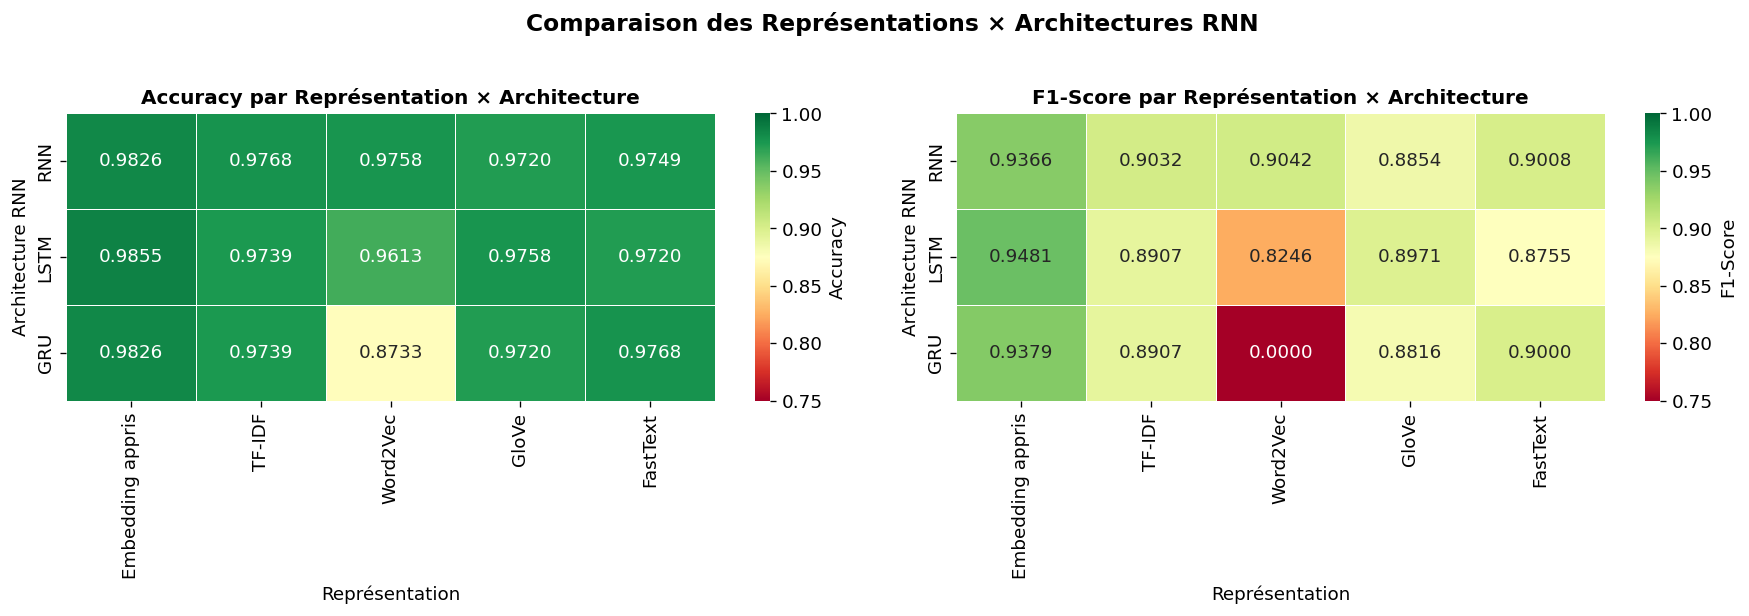

In [112]:
from pathlib import Path

print("CRÉATION DE LA HEATMAP")

# Prepare data for heatmap (take best result for each Representation x Architecture combo)
pivot_acc = results_df.pivot_table(
    index='Architecture',
    columns='Représentation',
    values='Accuracy',
    aggfunc='max'
)

pivot_f1 = results_df.pivot_table(
    index='Architecture',
    columns='Représentation',
    values='F1-Score',
    aggfunc='max'
)

# Ensure proper column order
col_order = ['Embedding appris', 'TF-IDF', 'Word2Vec', 'GloVe', 'FastText']
pivot_acc = pivot_acc[[c for c in col_order if c in pivot_acc.columns]]
pivot_f1 = pivot_f1[[c for c in col_order if c in pivot_f1.columns]]

# Row order
row_order = ['RNN', 'LSTM', 'GRU']
pivot_acc = pivot_acc.reindex([r for r in row_order if r in pivot_acc.index])
pivot_f1 = pivot_f1.reindex([r for r in row_order if r in pivot_f1.index])

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Comparaison des Représentations × Architectures RNN",
             fontsize=14, fontweight='bold', y=1.02)

# Plot Accuracy heatmap
sns.heatmap(
    pivot_acc,
    annot=True,
    fmt='.4f',
    cmap='RdYlGn',
    vmin=0.75,
    vmax=1.0,
    linewidths=0.5,
    ax=axes[0],
    cbar_kws={'label': 'Accuracy'}
)
axes[0].set_title('Accuracy par Représentation × Architecture', fontsize=12, fontweight='bold')
axes[0].set_xlabel("Représentation", fontsize=11)
axes[0].set_ylabel("Architecture RNN", fontsize=11)

# Plot F1-Score heatmap
sns.heatmap(
    pivot_f1,
    annot=True,
    fmt='.4f',
    cmap='RdYlGn',
    vmin=0.75,
    vmax=1.0,
    linewidths=0.5,
    ax=axes[1],
    cbar_kws={'label': 'F1-Score'}
)
axes[1].set_title('F1-Score par Représentation × Architecture', fontsize=12, fontweight='bold')
axes[1].set_xlabel("Représentation", fontsize=11)
axes[1].set_ylabel("Architecture RNN", fontsize=11)

fig.tight_layout()

# Save figure
out_path = Path("tmp") / "fig3_heatmap.png"
out_path.parent.mkdir(exist_ok=True)
fig.savefig(out_path, dpi=150, bbox_inches='tight')
print(f"Heatmap sauvegardée: {out_path.resolve()}")
plt.show()

In [113]:
print("RÉSUMÉ FINAL DE L'EXPÉRIMENTATION")
print(f"\nTotal de méthodes testées: {len(comparatif)}")
print(f"Meilleur F1-Score: {comparatif['F1-Score'].max():.4f}")
print(f"Meilleure Accuracy: {comparatif['Accuracy'].max():.4f}")

# Statistics by representation
print("STATISTIQUES PAR REPRÉSENTATION")
for rep in comparatif['Représentation'].unique():
    rep_data = comparatif[comparatif['Représentation'] == rep]
    print(f"\n{rep}:")
    print(f"  Méthodes: {len(rep_data)}")
    print(f"  Accuracy moyenne: {rep_data['Accuracy'].mean():.4f}")
    print(f"  F1-Score moyen: {rep_data['F1-Score'].mean():.4f}")
    print(f"  Temps moyen: {rep_data['Temps (s)'].mean():.2f}s")



RÉSUMÉ FINAL DE L'EXPÉRIMENTATION

Total de méthodes testées: 16
Meilleur F1-Score: 0.9481
Meilleure Accuracy: 0.9855
STATISTIQUES PAR REPRÉSENTATION

Embedding appris:
  Méthodes: 3
  Accuracy moyenne: 0.9836
  F1-Score moyen: 0.9409
  Temps moyen: 16.86s

Word2Vec:
  Méthodes: 4
  Accuracy moyenne: 0.9393
  F1-Score moyen: 0.6311
  Temps moyen: 17.92s

TF-IDF:
  Méthodes: 3
  Accuracy moyenne: 0.9749
  F1-Score moyen: 0.8949
  Temps moyen: 10.03s

FastText:
  Méthodes: 3
  Accuracy moyenne: 0.9745
  F1-Score moyen: 0.8921
  Temps moyen: 7.15s

GloVe:
  Méthodes: 3
  Accuracy moyenne: 0.9732
  F1-Score moyen: 0.8880
  Temps moyen: 31.32s


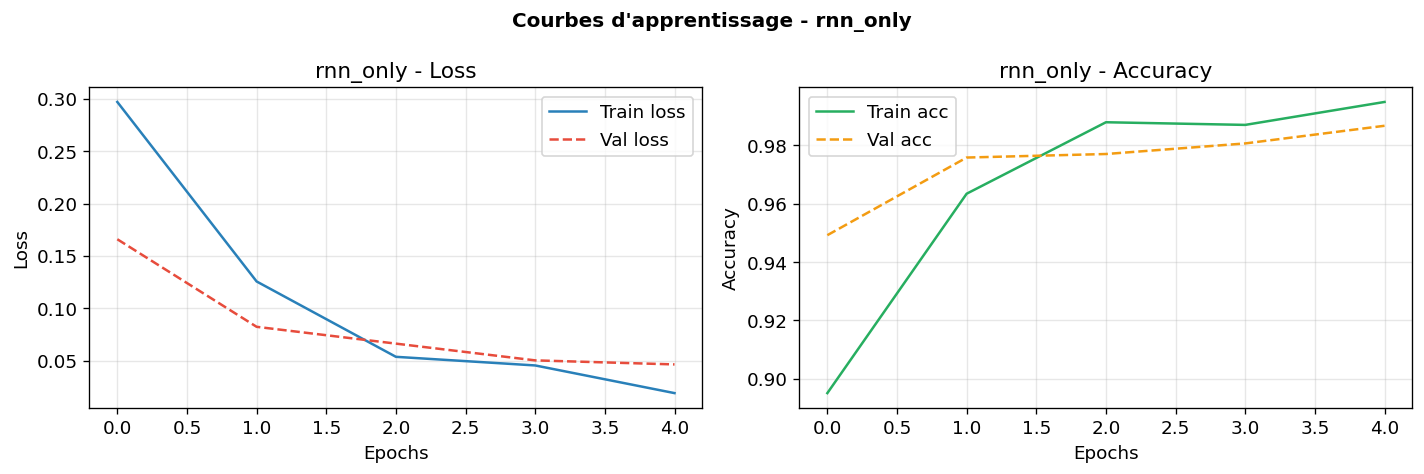

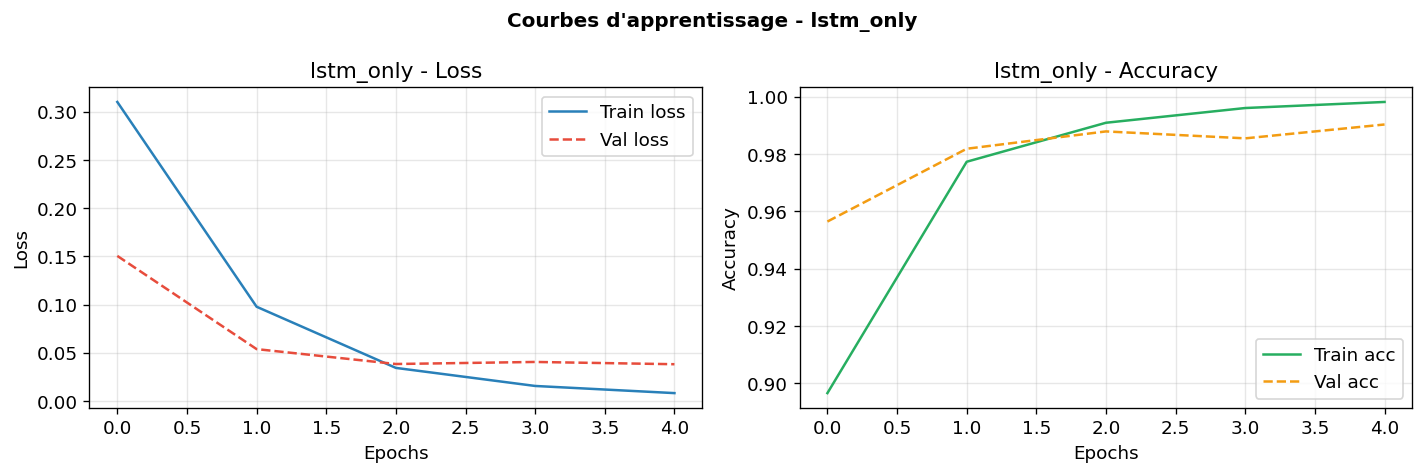

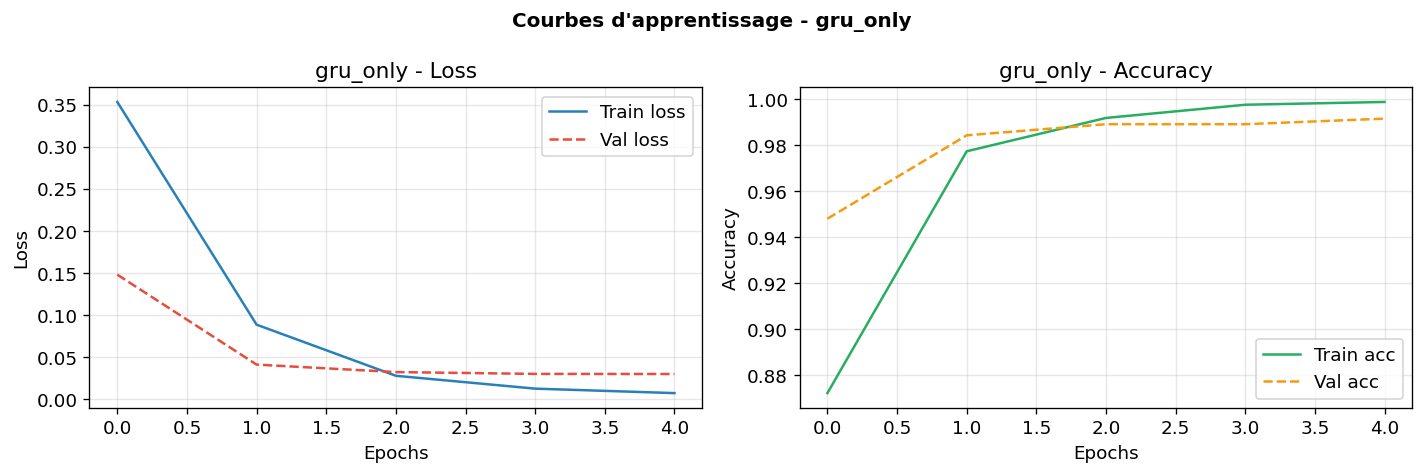

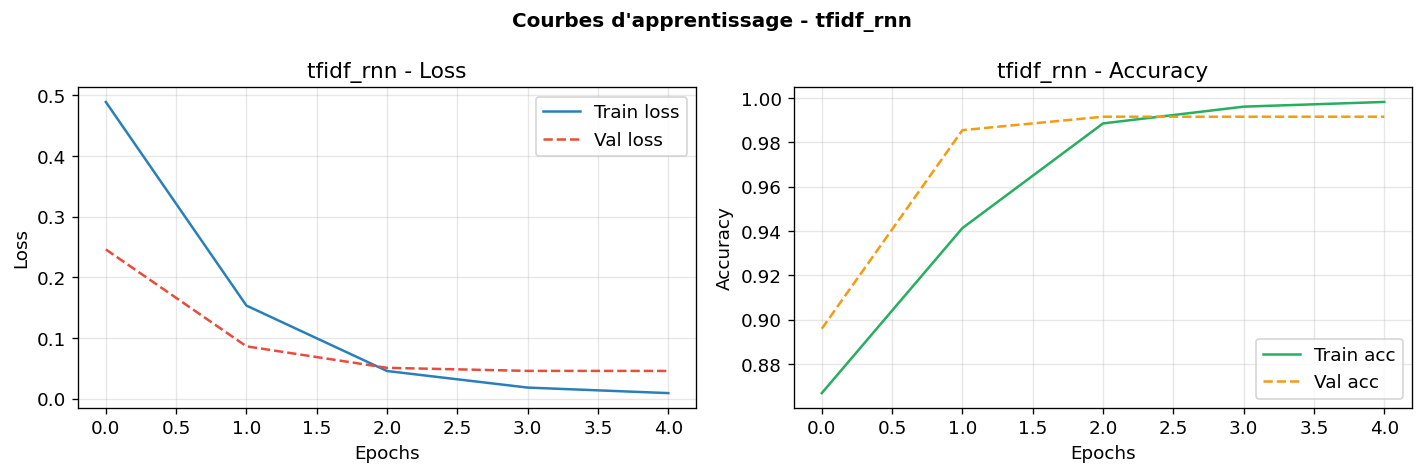

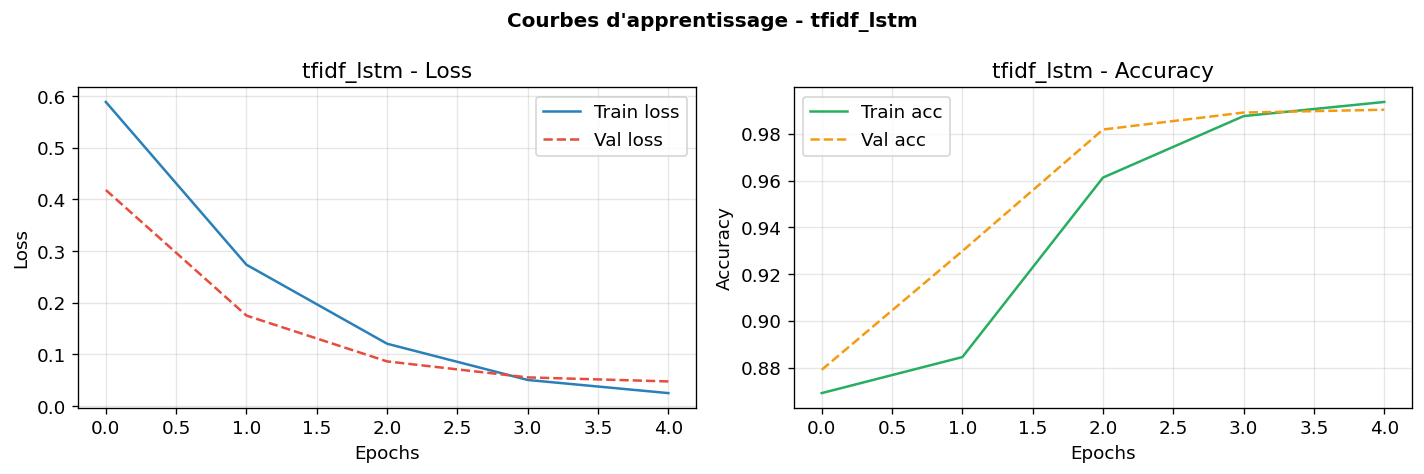

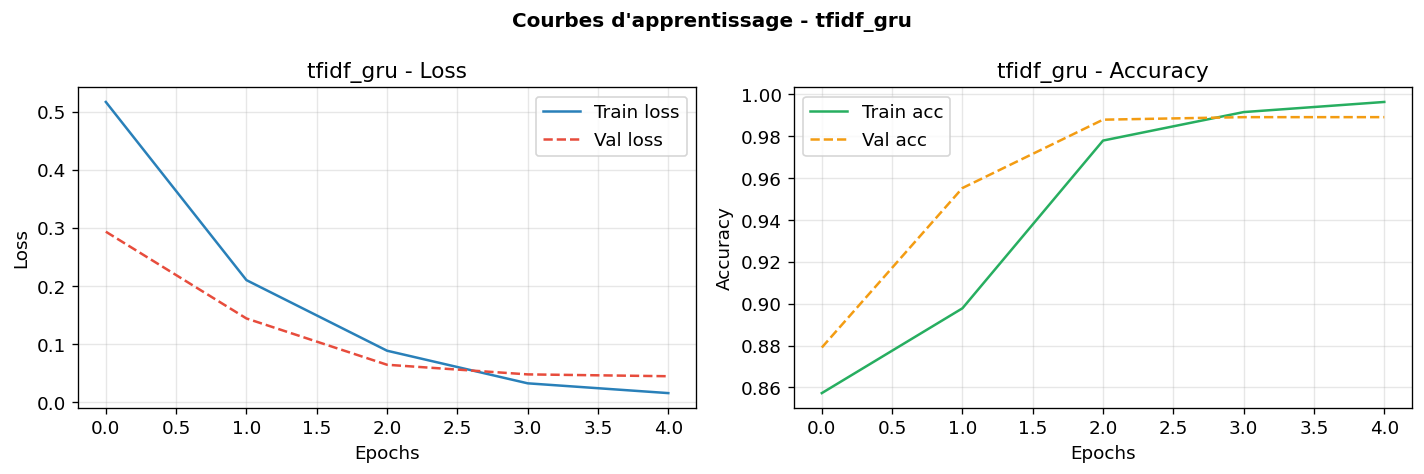

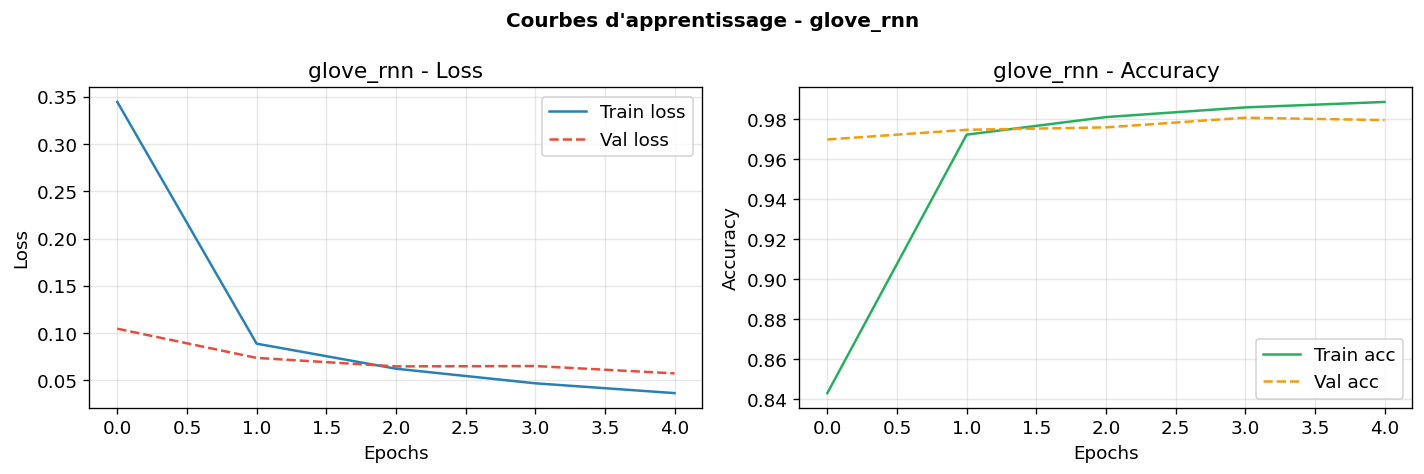

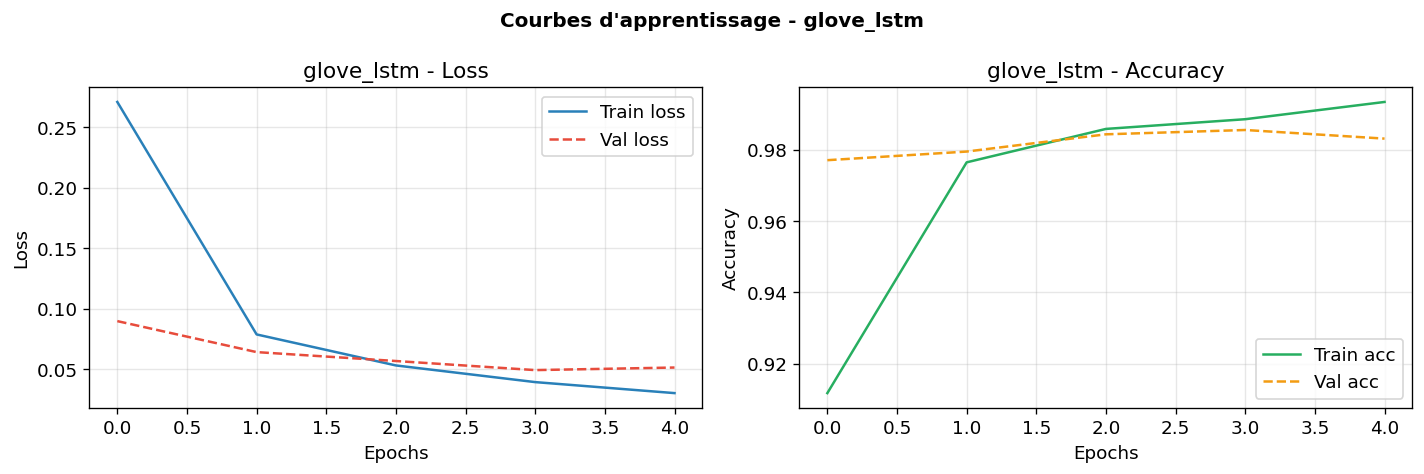

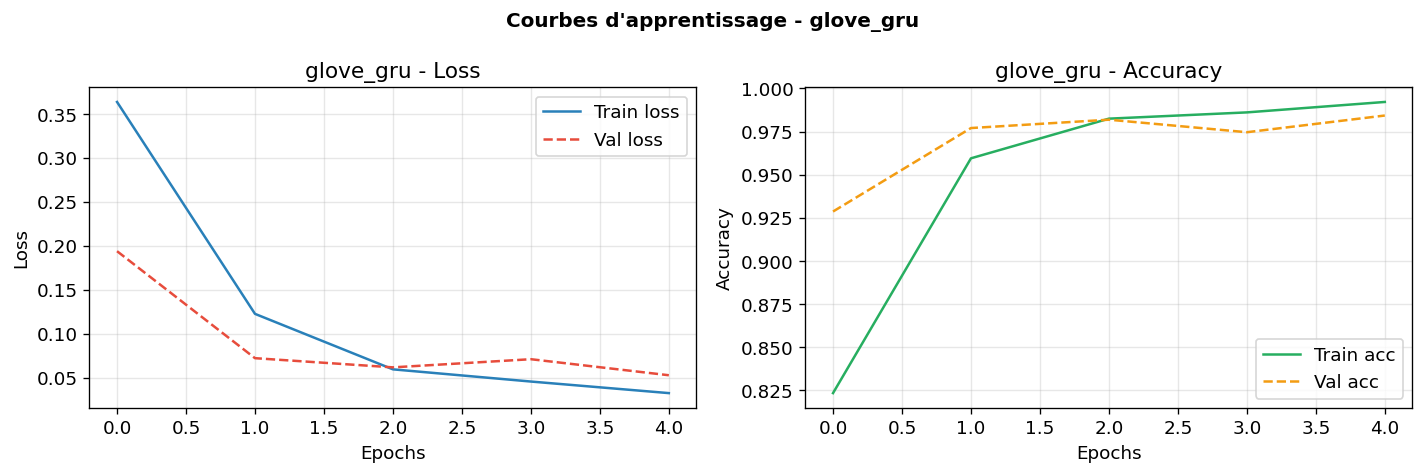

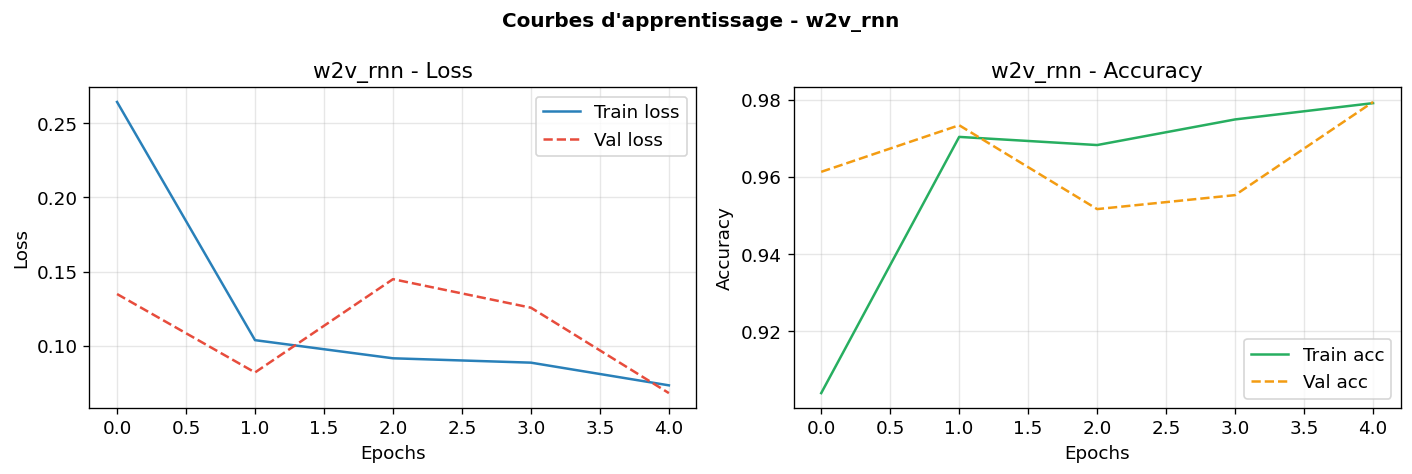

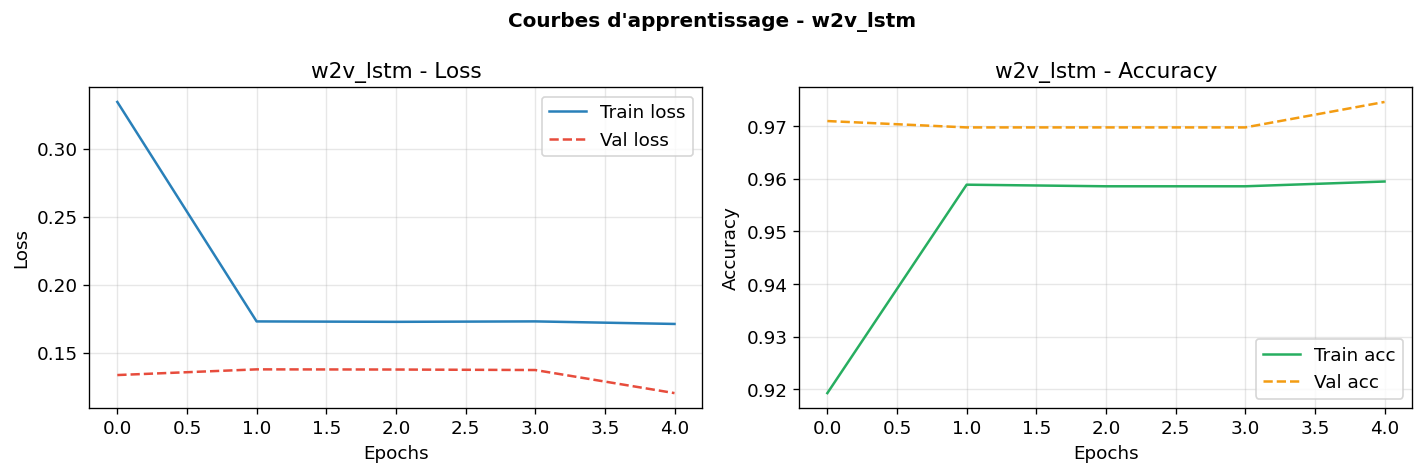

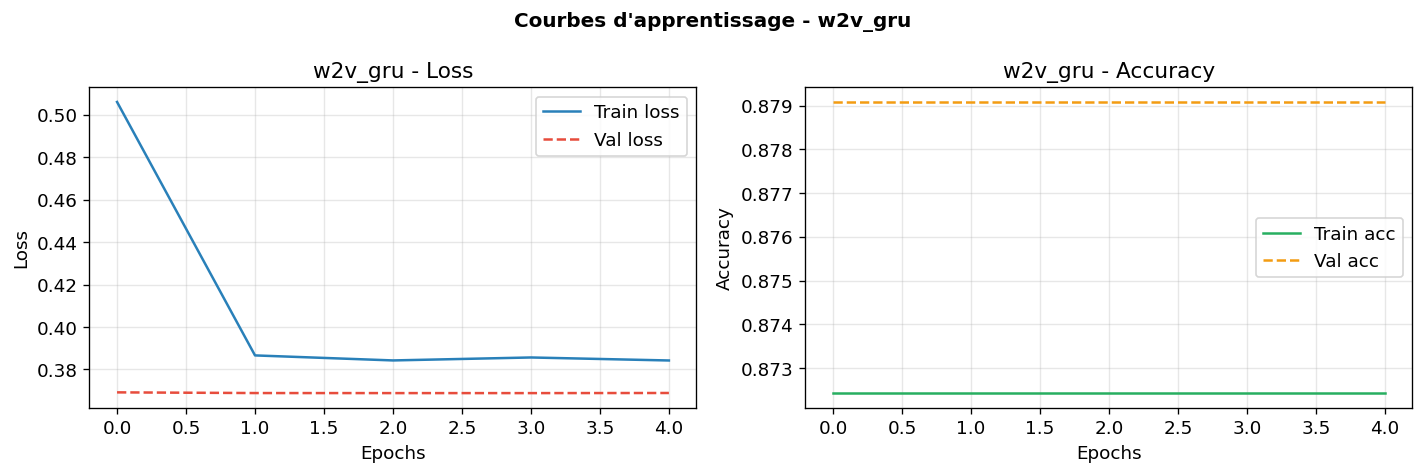

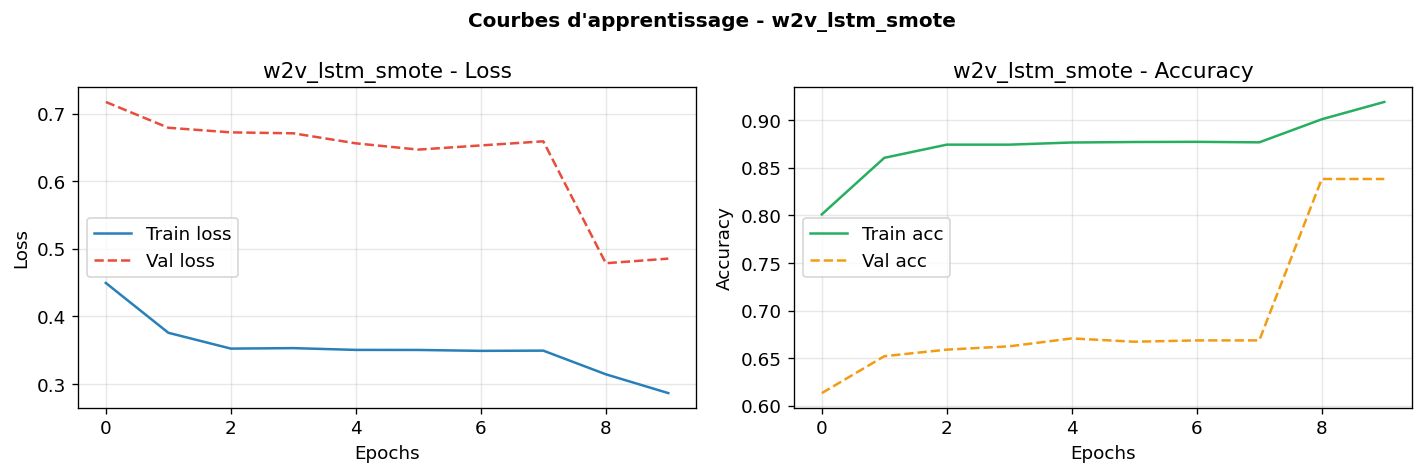

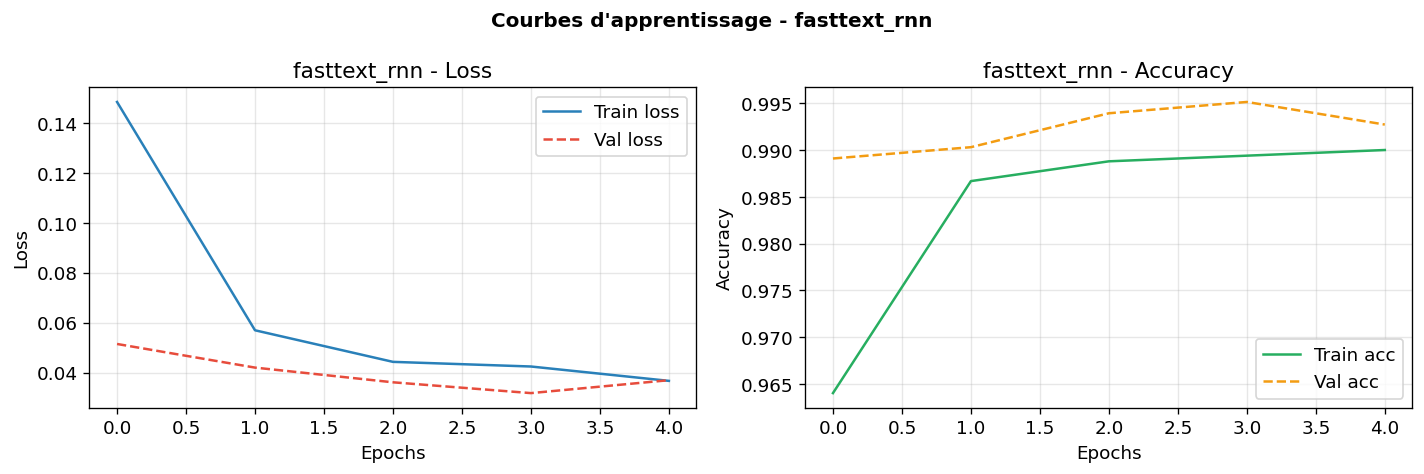

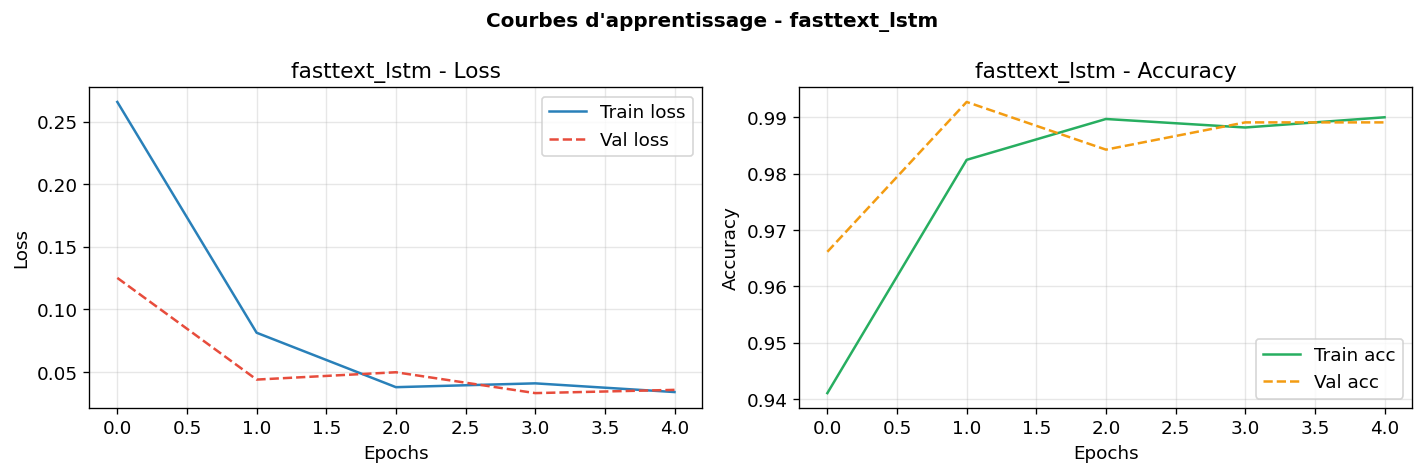

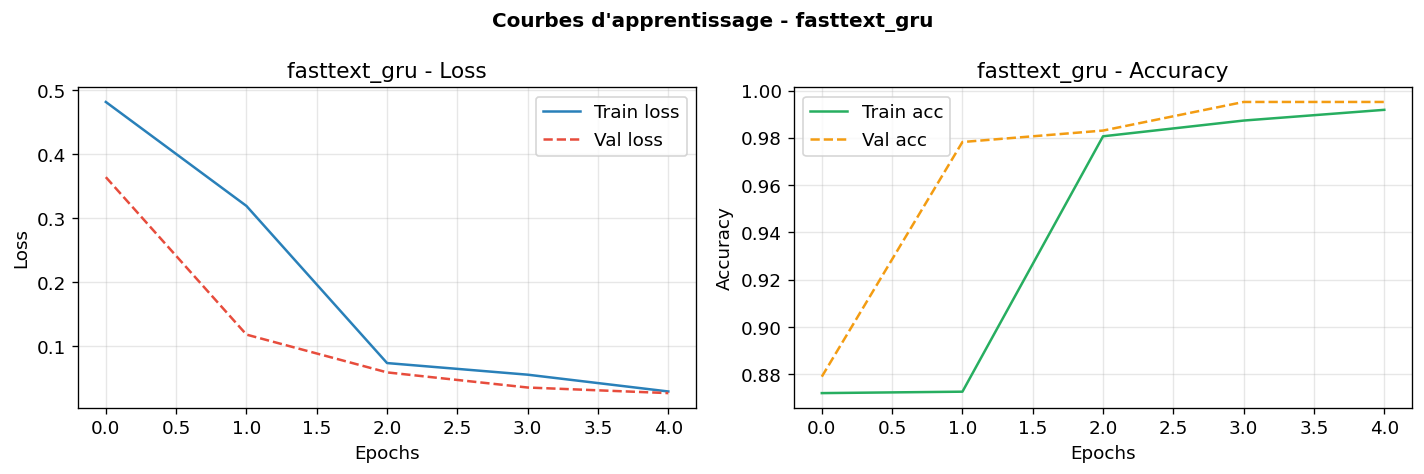

In [116]:
def plot_all_histories(results):
    for method, data in results.items():

        history = data.get("history", None)

        if history is None:
            print(f"[WARN] Pas d'history pour {method}")
            continue

        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        # --- LOSS ---
        axes[0].plot(history["loss"], label="Train loss", color="#2980b9")
        axes[0].plot(history["val_loss"], label="Val loss", color="#e74c3c", linestyle="--")
        axes[0].set_title(f"{method} - Loss")
        axes[0].set_xlabel("Epochs")
        axes[0].set_ylabel("Loss")
        axes[0].legend()
        axes[0].grid(alpha=0.3)

        # --- ACCURACY ---
        axes[1].plot(history["accuracy"], label="Train acc", color="#27ae60")
        axes[1].plot(history["val_accuracy"], label="Val acc", color="#f39c12", linestyle="--")
        axes[1].set_title(f"{method} - Accuracy")
        axes[1].set_xlabel("Epochs")
        axes[1].set_ylabel("Accuracy")
        axes[1].legend()
        axes[1].grid(alpha=0.3)

        fig.suptitle(f"Courbes d'apprentissage - {method}", fontsize=12, fontweight="bold")

        plt.tight_layout()
        plt.show()

plot_all_histories(results)

CRÉATION DES COURBES ROC
[WARN] Pas de données pour Word2Vec(50d)
[WARN] Pas de données pour GloVe(200d)
[WARN] Pas de données pour FastText(100d)


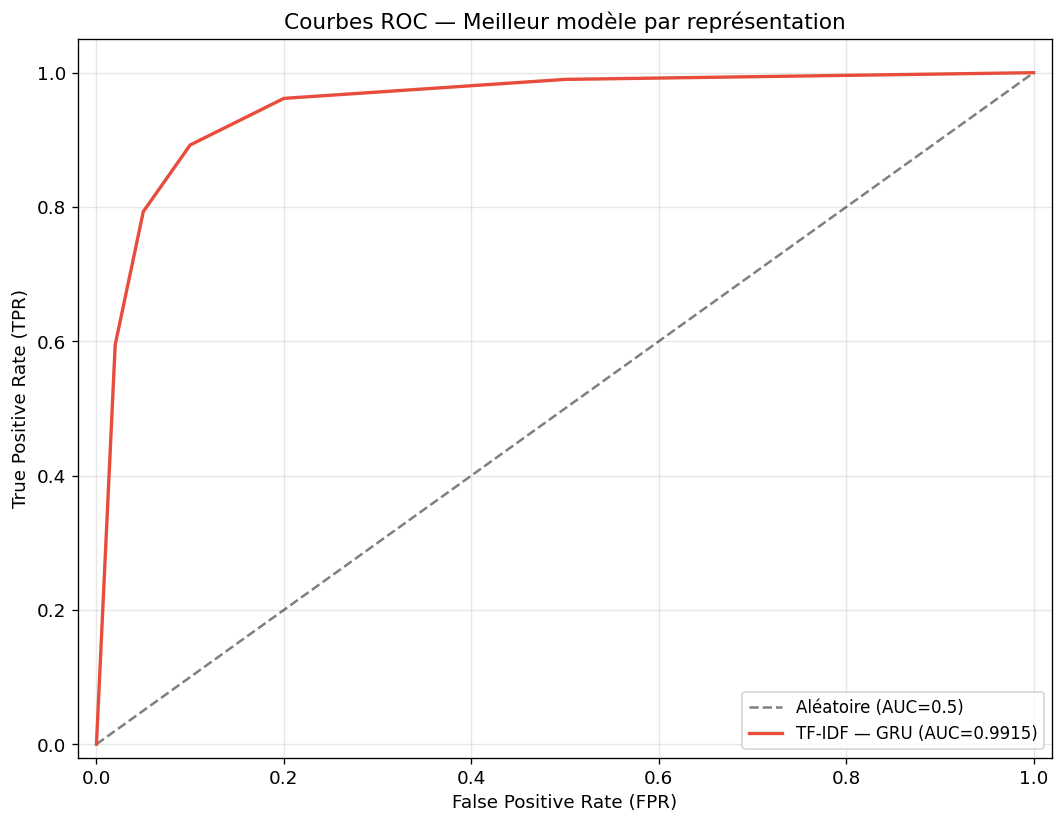

Figure ROC sauvegardée: tmp/fig5_roc.png


In [120]:
print(results_df.columns)

Index(['Méthode', 'Représentation', 'Architecture', 'Config', 'Accuracy',
       'F1-Score', 'AUC-ROC', 'Temps (s)'],
      dtype='str')


FIGURE 7 — COMPARAISON TEMPS & F1


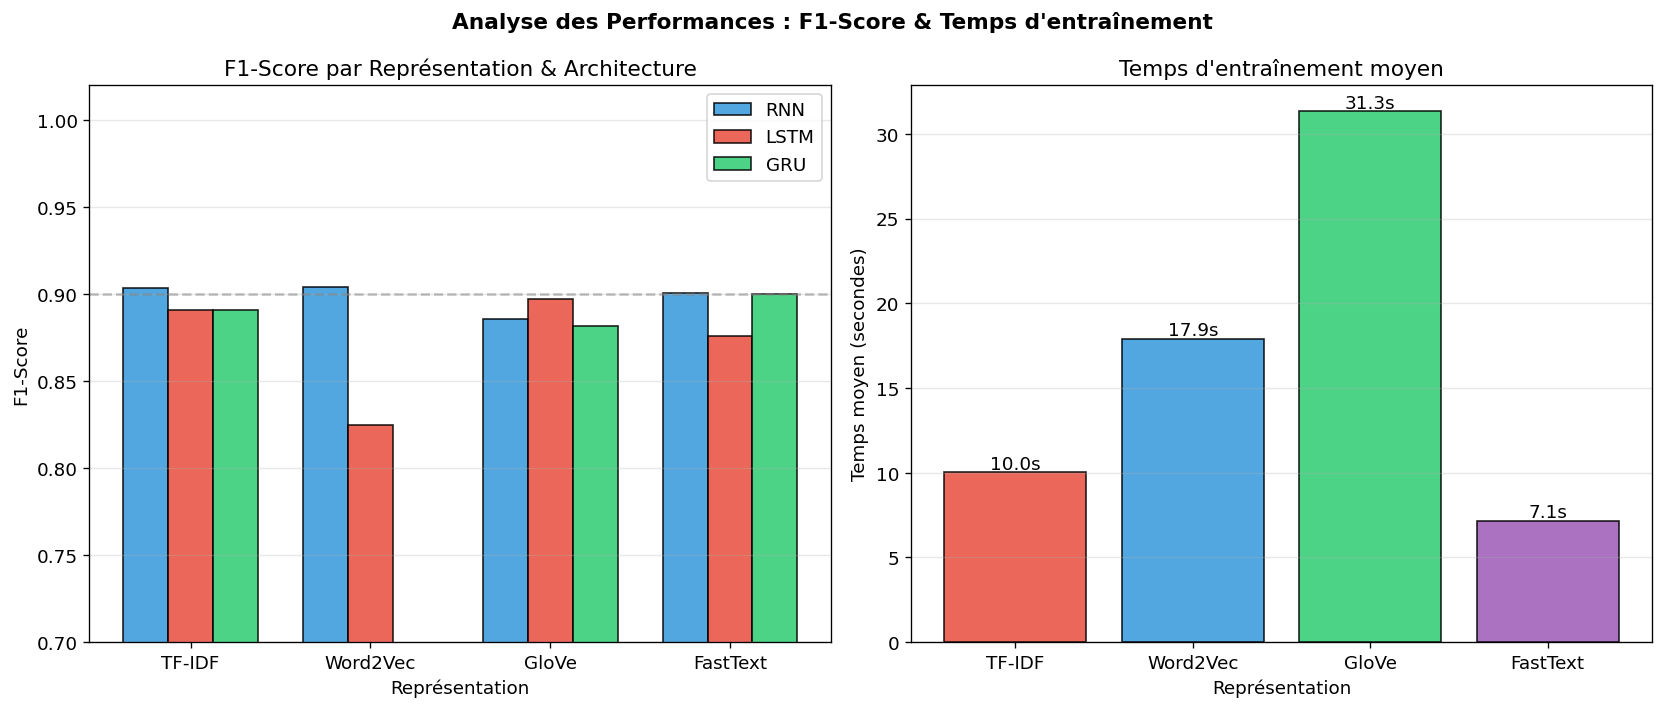

Figure sauvegardée: tmp/fig7_comparison.png


In [ ]:
print("FIGURE 7 — COMPARAISON TEMPS & F1")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

fig.suptitle(
    "Analyse des Performances : F1-Score & Temps d'entraînement",
    fontsize=13,
    fontweight='bold'
)

reps = ['TF-IDF', 'Word2Vec', 'GloVe', 'FastText']
archs = ['RNN', 'LSTM', 'GRU']

x = np.arange(len(reps))
width = 0.25

arch_colors = {
    'RNN': '#3498db',
    'LSTM': '#e74c3c',
    'GRU': '#2ecc71'
}


for i, arch in enumerate(archs):
    vals = []

    for r in reps:
        subset = results_df[
            (results_df["Représentation"].str.contains(r, na=False)) &
            (results_df["Architecture"].str.contains(arch, na=False))
        ]

        if subset.empty:
            vals.append(0)
        else:
            vals.append(subset["F1-Score"].max()) 

    axes[0].bar(
        x + i * width,
        vals,
        width,
        label=arch,
        color=arch_colors[arch],
        alpha=0.85,
        edgecolor='black'
    )

axes[0].set_xlabel("Représentation")
axes[0].set_ylabel("F1-Score")
axes[0].set_title("F1-Score par Représentation & Architecture")
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(reps)
axes[0].legend()
axes[0].set_ylim(0.7, 1.02)
axes[0].axhline(0.9, color='gray', linestyle='--', alpha=0.5)
axes[0].grid(axis='y', alpha=0.3)

mean_time = []

for r in reps:
    subset = results_df[results_df["Représentation"].str.contains(r, na=False)]

    if subset.empty:
        mean_time.append(0)
    else:
        mean_time.append(subset["Temps (s)"].mean()) 
bar_colors = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6']

bars = axes[1].bar(
    reps,
    mean_time,
    color=bar_colors,
    edgecolor='black',
    alpha=0.85
)

for bar, val in zip(bars, mean_time):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.2,
        f'{val:.1f}s',
        ha='center',
        fontsize=11
    )

axes[1].set_xlabel("Représentation")
axes[1].set_ylabel("Temps moyen (secondes)")
axes[1].set_title("Temps d'entraînement moyen")
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()

out_path = "tmp/fig7_comparison.png"
plt.savefig(out_path, dpi=150, bbox_inches='tight')

plt.show()

print(f"Figure sauvegardée: {out_path}")